# Сборный проект — 2

### Описание проекта

**Цель исследования**

Помочь бизнесу предсказывать удовлетворенность сотрудников работой и предсказывать отток сотрудников

**Задачи исследования**
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**Исходные данные**

Данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 

**Данное исследование разделим на несколько частей.**

***Часть 1. Задача 1 - предсказание уровня удовлетворённости сотрудника:***
* [1.0 получение общей информации, загрузка библиотек.](#1-distinct)
* [1.1 Загрузка данных.](#1.1-distinct)
* [2. Предобработка данных.](#2-distinct)
* [3. Исследовательский анализ данных.](#3-distinct)
* [4. Подготовка данных.](#4-distinct)
* [5. Обучение моделей.](#5-distinct)
* [6. Вывод по 1 задаче.](#6-distinct)


***Часть 2. Подготовка данных:***
* [1. Загрузка данных.](#1-bullet)
* [2. Предобработка данных.](#2-bullet)
* [3. Исследовательский анализ данных.](#3-bullet)
* [3.1 Портрет уволившегося сотрудника.](#3.1-bullet)
* [4. Добавление нового входного признака.](#4-bullet)
* [5. Подготовка данных.](#5-bullet)
* [6. Обучение моделей.](#6-bullet)
* [7. Вывод по 2 задаче.](#7-bullet)

[Общий вывод.](#10-bullet)

<a id='#1-distinct'></a>
## Задача 1: предсказание уровня удовлетворённости сотрудника

Для этой задачи заказчик предоставил данные с признаками:
- id — уникальный идентификатор сотрудника;
- dept — отдел, в котором работает сотрудник;
- level — уровень занимаемой должности;
- workload — уровень загруженности сотрудника;
- employment_years — длительность работы в компании (в годах);
- last_year_promo — показывает, было ли повышение за последний год;
- last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
- supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
- salary — ежемесячная зарплата сотрудника;
- job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

In [1]:
!pip install matplotlib==3.8.3 -q

In [2]:
!pip install seaborn==0.13.2 -q

In [3]:
!pip install scikit-learn==1.6 -q

In [4]:
!pip install phik -q

In [5]:
!pip install shap -q

In [6]:
!pip install optuna -q
!pip install optuna-integration[sklearn] -q

In [7]:
!pip install imbalanced-learn -q

In [188]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import phik
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score, recall_score, accuracy_score, \
                            r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, \
                            make_scorer

# загружаем класс pipeline
from imblearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, \
    							  MinMaxScaler, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# импортируем класс OptunaSearchCV
from optuna.integration import OptunaSearchCV 
from optuna import distributions

# загружаем нужные модели
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR

# загружаем методы отбора признаков
from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import f_classif, mutual_info_classif
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler


In [9]:
RANDOM_STATE= 57
TEST_SIZE= 0.25
plt.rcParams["figure.figsize"] = (12,6)

#### Пользовательские функции

In [10]:
def df_hist(df, bins=20, id=0):

    # Удаление столбца id из датафрейма для создания графиков
    if id:
        df = df.drop(columns=['id'])

    # Определение целочисленных столбцов 
    count_col = df.select_dtypes('number')
    count_col = count_col.columns[count_col.nunique() < 11]

    # Создание гистограммы и boxplot для непрерывных данных
    for col in df.select_dtypes('number').drop(columns=count_col):
        fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
        df[col].hist(bins=bins, ax=ax1)
        ax1.set_title(f'Гистограмма по столбцу "{col}"')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Количество')
        df.boxplot(column=col, ax=ax2, vert=False)
        ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax2.set_title(f'Ящик с усами по столбцу "{col}"')
        plt.xlabel(col)
        plt.show();

    # Создание countplot для целочесленных данных
    for col in df[count_col]:
        sns.countplot(data=df, x=col)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

    # Создание countplot для категориальных данных
    for col in df.select_dtypes('object'):
        sns.countplot(data=df, x=col)
        if df[col].nunique() > 3:
            plt.xticks(rotation=90)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

In [11]:
def df_info(dict_df):
    for key, value in dict_df.items():
        print(key)
        value.info()
        display(value.head(5))
        print('----------------------------------------------------')
        print('\n')

In [12]:
def df_pred(dict_df):
    for key, value in dict_df.items():
        print(key)
        print('Явных дубликатов', value.duplicated().sum())
        print('Максимум пропусков', value.isna().sum().max())
        print('----------------------------------------------------')
        print('\n')

In [13]:
def df_value(dict_df):
    for key, value in dict_df.items():
        print(f'Датафрейм: {key}')
        print('\n')
        for col in value.select_dtypes('object').columns:
            display(value[col].value_counts())
            print('\n')
        print('----------------------------------------------------')
        print('\n')

In [14]:
def df_corr(dict_df, continuous_features=None):
    for df_k, df_v in dict_df.items():
        if continuous_features is None:
            continuous_features = df_v.select_dtypes('number').columns
        if len(df_v.columns) > 1:
            plt.figure(figsize=(15,15));
            ax = sns.heatmap(df_v.phik_matrix(interval_cols=continuous_features), annot=True, fmt='.2f', cmap='coolwarm');
            ax.set(xlabel="", ylabel="", title=f'Корреляционная матрица датафрейма {df_k}')
            plt.show();

In [15]:
def df_set_index(dict_df, index='', lst=None):
    n=0
    for df_k, df_v in dict_df.items():
        try:
            dict_df[df_k] = df_v.set_index(index)
            print(f'"{df_k}" индекс обновлен на "{index}"')
        except KeyError:
            print(f'В "{df_k}" отсутствует столбец "{index}"')
        if lst:
            lst[n] = dict_df[df_k]
            n += 1

In [16]:
def smape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    metric = 100 * np.mean(abs(y_true - y_pred) / ((abs(y_true) + abs(y_pred)) / 2 + 1e-8))
    return metric

smape_score = make_scorer(
    smape,
    greater_is_better=False
)

In [17]:
# проверка работы модели на тестовой выборке
# рассчет прогноза на тестовых данных
def show_metrics_regressor(df, X_test, y_test, X_test_true=None, y_test_true=None):
    predictions = df.predict(X_test)

    y_test = np.array(y_test).flatten()
    predictions = np.array(predictions).flatten()

    valid = [smape(y_test, predictions),
            r2_score(y_test, predictions),
            mean_absolute_error(y_test, predictions),
            mean_squared_error(y_test, predictions),
            root_mean_squared_error(y_test, predictions)]
    
    if y_test_true is not None:
        predictions_test_true = df.predict(X_test_true)
        y_test_true = np.array(y_test_true).flatten()
        predictions_test_true = np.array(predictions_test_true).flatten()
        
        test_true = [smape(y_test_true, predictions_test_true),
            r2_score(y_test_true, predictions_test_true),
            mean_absolute_error(y_test_true, predictions_test_true),
            mean_squared_error(y_test_true, predictions_test_true),
            root_mean_squared_error(y_test_true, predictions_test_true)]
        display(pd.DataFrame(data=[valid, test_true],
                            columns=['SMAPE','R2','MAE','MSE','RMSE'],
                            index=['На валидационной выборке','На тестовой выборке']).round(3)) 

    else:
        display(pd.DataFrame(data=[valid],
                            columns=['SMAPE','R2','MAE','MSE','RMSE'],
                            index=['На тестовой выборке']).round(3))    

In [18]:
# проверка работы модели на тестовой выборке
# рассчет прогноза на тестовых данных
def show_metrics_classifier(df, X_test, y_test, X_test_true=None, y_test_true=None):
    predictions = df.predict(X_test)

    y_test = np.array(y_test).flatten()
    predictions = np.array(predictions).flatten()

    valid = [roc_auc_score(y_test, predictions),
            accuracy_score(y_test,predictions),
            f1_score(y_test,predictions)]
        
    if y_test_true is not None:
        predictions_valid = df.predict(X_test_true)
        y_test_true = np.array(y_test_true).flatten()
        predictions_valid = np.array(predictions_valid).flatten()
        test = [roc_auc_score(y_test_true, predictions_valid),
            	 accuracy_score(y_test_true,predictions_valid),
            	 f1_score(y_test_true,predictions_valid)]

        display(pd.DataFrame(data=[valid,test],
                                columns=['ROC-AUC','Accuracy','f1'],
                                index=['На валидационной выборке','На тестовой выборке']).round(3))
    else:
        display(pd.DataFrame(data=[valid],
						columns=['ROC-AUC','Accuracy','f1'],
						index=['На тестовой выборке']).round(3))    
        

In [19]:
# проверка работы модели на тестовой выборке
# рассчет прогноза на тестовых данных
def show_metrics_classifier(df, X_test, y_test, X_valid=None, y_valid=None):
    predictions = df.predict(X_test)

    y_test = np.array(y_test).flatten()
    predictions = np.array(predictions).flatten()

    test = [roc_auc_score(y_test, predictions),
            accuracy_score(y_test,predictions),
            f1_score(y_test,predictions)]
        
    if y_valid is not None:
        predictions_valid = df.predict(X_valid)
        y_valid = np.array(y_valid).flatten()
        predictions_valid = np.array(predictions_valid).flatten()
        valid = [roc_auc_score(y_valid, predictions_valid),
            	 accuracy_score(y_valid,predictions_valid),
            	 f1_score(y_valid,predictions_valid)]

        display(pd.DataFrame(data=[valid,test],
                                columns=['ROC-AUC','Accuracy','f1'],
                                index=['На валидационной выборке','На тестовой выборке']).round(3))
    else:
        display(pd.DataFrame(data=[test],
						columns=['ROC-AUC','Accuracy','f1'],
						index=['На тестовой выборке']).round(3))    
        

In [20]:
def df_randomized_search_regressor(pipe, param_grid, n_iter=7):
    return RandomizedSearchCV(
    pipe, 
    param_grid, 
    cv=5,
    n_iter=n_iter,
    scoring={'smape':smape_score,
             'r2':'r2',
             'mae':'neg_mean_absolute_error',
             'mse':'neg_mean_squared_error', 
             'rmse':'neg_root_mean_squared_error'},
    refit='smape',
    random_state=RANDOM_STATE,
    # n_jobs=-1,
    )

In [21]:
def df_randomized_search_classifier(pipe, param_grid, n_iter=7):
    return RandomizedSearchCV(
    pipe, 
    param_grid, 
    cv=5,
    n_iter=n_iter,
    scoring=['roc_auc','accuracy','f1'],
    refit='roc_auc',
    random_state=RANDOM_STATE,
    # n_jobs=-1
    )

In [22]:
def show_shap(best_model, X_train, X_test):
    models = best_model.named_steps['models']
    preprocessor = best_model.named_steps['preprocessor']

    explainer = shap.KernelExplainer(models.predict,preprocessor.transform(X_train), feature_names=preprocessor.get_feature_names_out())

    shap_values = explainer(preprocessor.transform(X_test))
    shap.plots.bar(shap_values, max_display=17)

<a id='#1.1-distinct'></a>
### Шаг 1. Загрузка данных

Загрузите файлы с данными:

Тренировочная выборка:
- train_job_satisfaction_rate.csv

Входные признаки тестовой выборки:
- test_features.csv

Целевой признак тестовой выборки:
- test_target_job_satisfaction_rate.csv

In [23]:
try:
    train_job_satisfaction_rate = pd.read_csv('n1/train_job_satisfaction_rate.csv', index_col='id').sort_index()
    test_features = pd.read_csv('n1/test_features.csv', index_col='id').sort_index()
    test_target_job_satisfaction_rate = pd.read_csv('n1/test_target_job_satisfaction_rate.csv', index_col='id').sort_index()
except:
    train_job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv', index_col='id').sort_index()
    test_features = pd.read_csv('/datasets/test_features.csv', index_col='id').sort_index()
    test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv', index_col='id').sort_index()

In [24]:
list_1 = ('train_job_satisfaction_rate', 'test_features', 'test_target_job_satisfaction_rate')
dict_1 = {'train_job_satisfaction_rate':train_job_satisfaction_rate,
               'test_features':test_features,
               'test_target_job_satisfaction_rate':test_target_job_satisfaction_rate}


In [25]:
df_info(dict_1)

train_job_satisfaction_rate
<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 100954 to 999521
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   3994 non-null   object 
 1   level                  3996 non-null   object 
 2   workload               4000 non-null   object 
 3   employment_years       4000 non-null   int64  
 4   last_year_promo        4000 non-null   object 
 5   last_year_violations   4000 non-null   object 
 6   supervisor_evaluation  4000 non-null   int64  
 7   salary                 4000 non-null   int64  
 8   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 312.5+ KB


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
100954,purchasing,junior,low,1,no,no,4,15600,0.60
101057,sales,junior,low,1,no,yes,4,19200,0.45
101074,sales,junior,medium,2,no,no,2,20400,0.36
101081,sales,middle,low,2,no,no,4,28800,0.66
101129,technology,junior,medium,1,no,no,4,34800,0.71


----------------------------------------------------


test_features
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


----------------------------------------------------


test_target_job_satisfaction_rate
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1)
memory usage: 31.2 KB


,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69


----------------------------------------------------




<a id='#2-distinct'></a>
### Шаг 2. Предобработка данных

Изучите данные и сделайте выводы. При необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

#### Проверка на дубликаты, пропуски данных

In [26]:
df_pred(dict_1)

train_job_satisfaction_rate
Явных дубликатов 245
Максимум пропусков 6
----------------------------------------------------


test_features
Явных дубликатов 557
Максимум пропусков 2
----------------------------------------------------


test_target_job_satisfaction_rate
Явных дубликатов 1902
Максимум пропусков 0
----------------------------------------------------




Дубликаты в данных присутствуют.Так как на модель МО повляет тренировочная выборка, то удалим дубликаты в тренировочной выборке, а тестовую оставим без изменений 

Пропуски в данных исправим на этапе пайплайна. 

In [27]:
dict_1[list_1[0]] = dict_1[list_1[0]].drop_duplicates()

In [28]:
dict_1[list_1[0]].duplicated().sum()

0

In [29]:
df_pred(dict_1)

train_job_satisfaction_rate
Явных дубликатов 0
Максимум пропусков 6
----------------------------------------------------


test_features
Явных дубликатов 557
Максимум пропусков 2
----------------------------------------------------


test_target_job_satisfaction_rate
Явных дубликатов 1902
Максимум пропусков 0
----------------------------------------------------




Выявим неявные дубликаты и исправим. Также удалим пробелы из данных, чтобы не получить ложно заполенное значение типа "пробел"

In [30]:
for k, v in dict_1.items():
    dict_1[k] = v.replace(' ', '')

In [31]:
df_value(dict_1)

Датафрейм: train_job_satisfaction_rate




sales         1374
technology     818
purchasing     586
marketing      531
hr             440
Name: dept, dtype: int64

junior    1699
middle    1695
sinior     357
Name: level, dtype: int64

medium    1908
low       1125
high       722
Name: workload, dtype: int64

no     3635
yes     120
Name: last_year_promo, dtype: int64

...

junior    974
middle    854
sinior    171
Name: level, dtype: int64

medium    1043
low        593
high       363
             1
Name: workload, dtype: int64

no     1937
yes      63
Name: last_year_promo, dtype: int64

no     1738
yes     262
Name: last_year_violations, dtype: int64



----------------------------------------------------


Датафрейм: test_target_job_satisfaction_rate


----------------------------------------------------




#### Промежуточный вывод
Неявные дубликаты не найдены. Пропуски будут устранены на этапе пайплайнов

<a id='#3-distinct'></a>
### Шаг 3. Исследовательский анализ данных
Исследуйте все признаки и сделайте выводы о том, как их нужно подготовить.

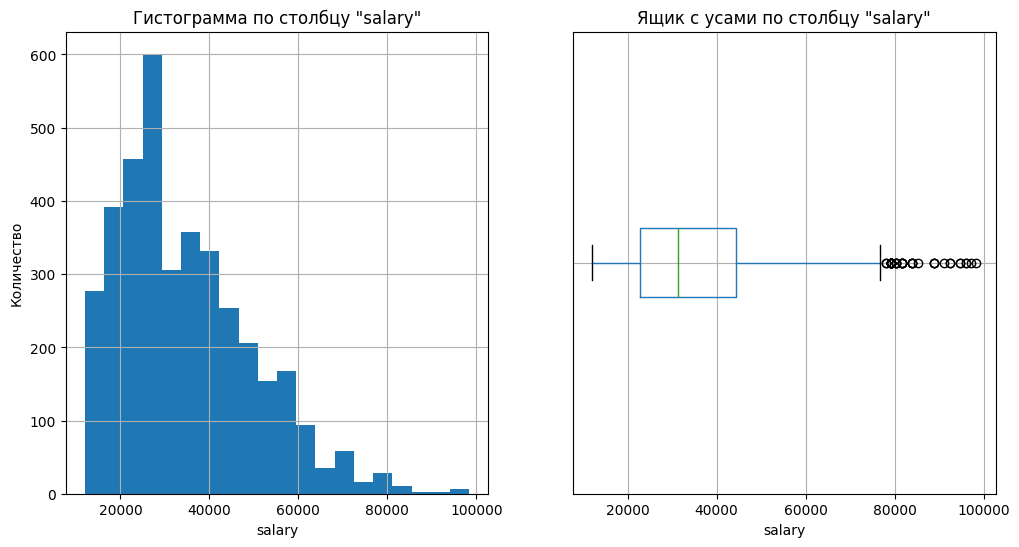

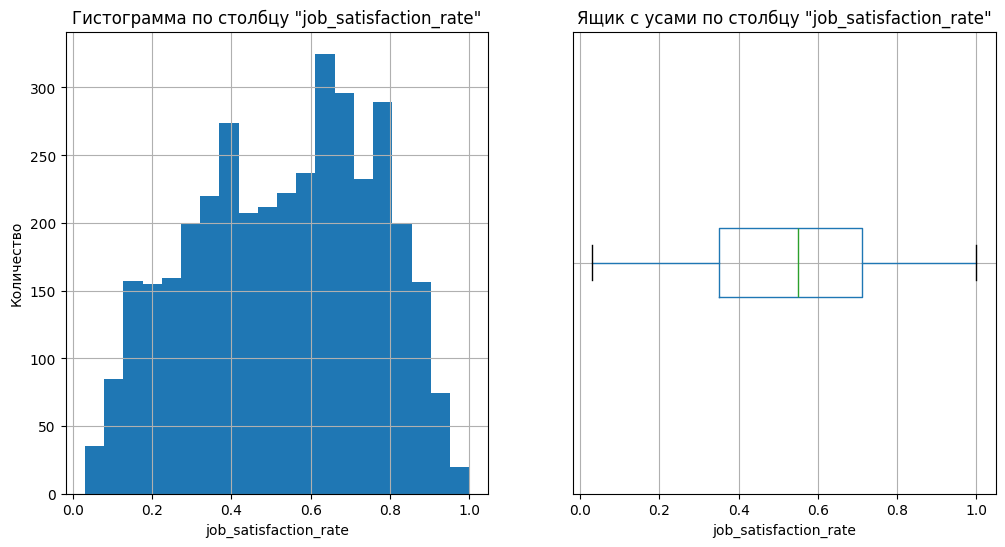

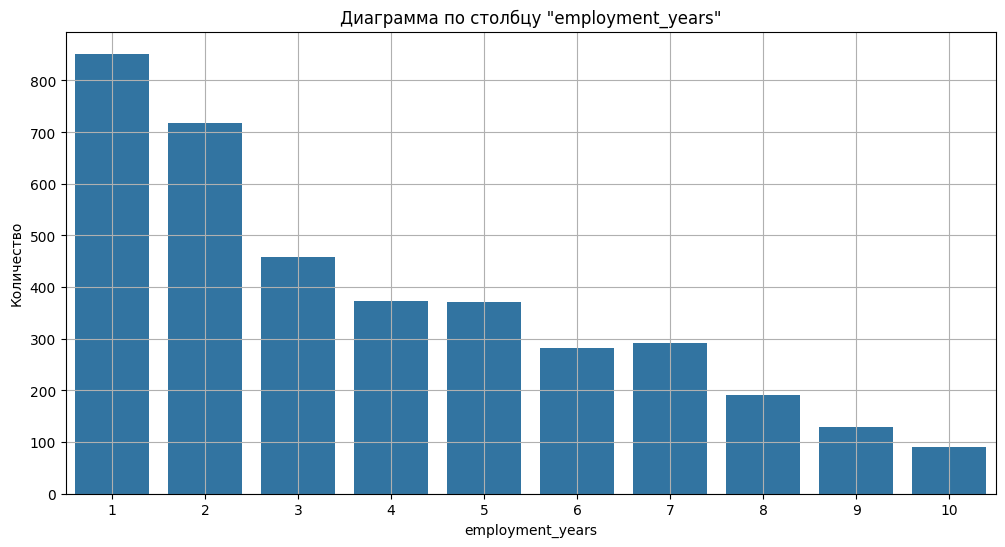

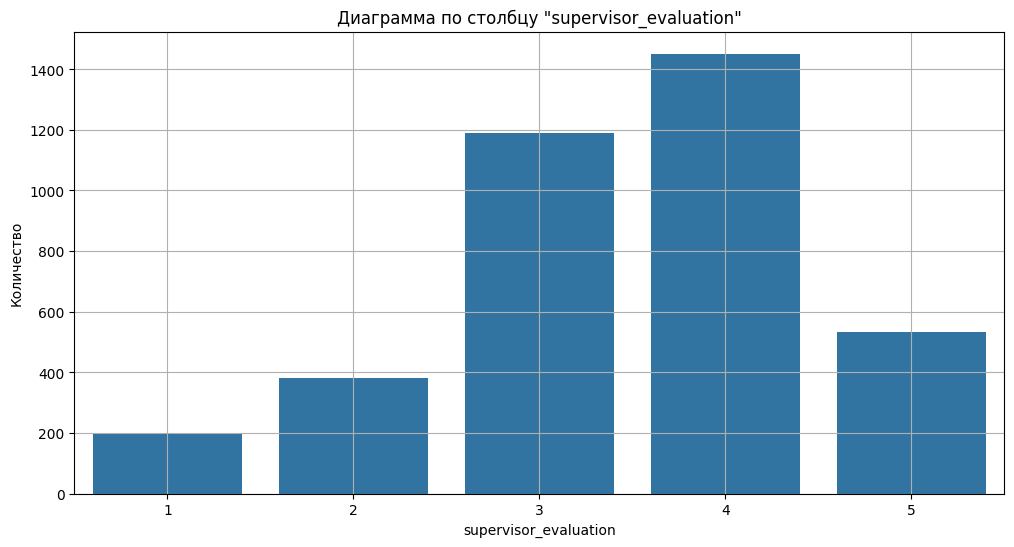

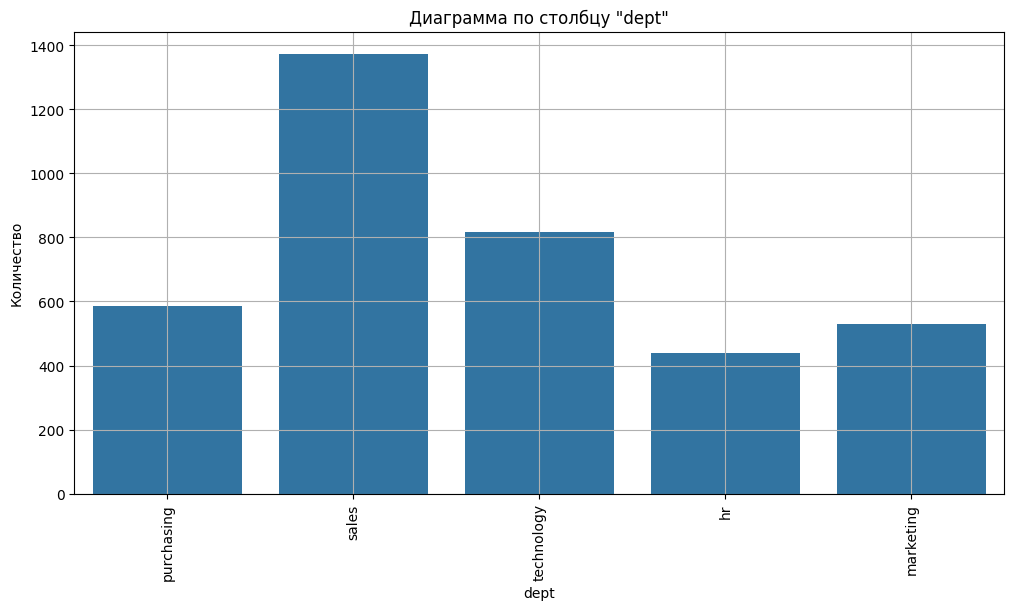

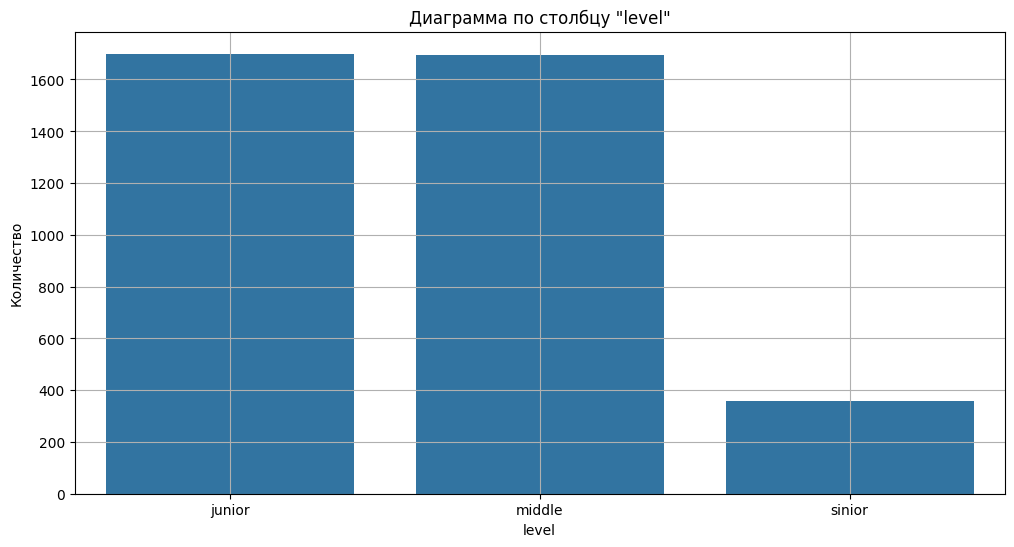

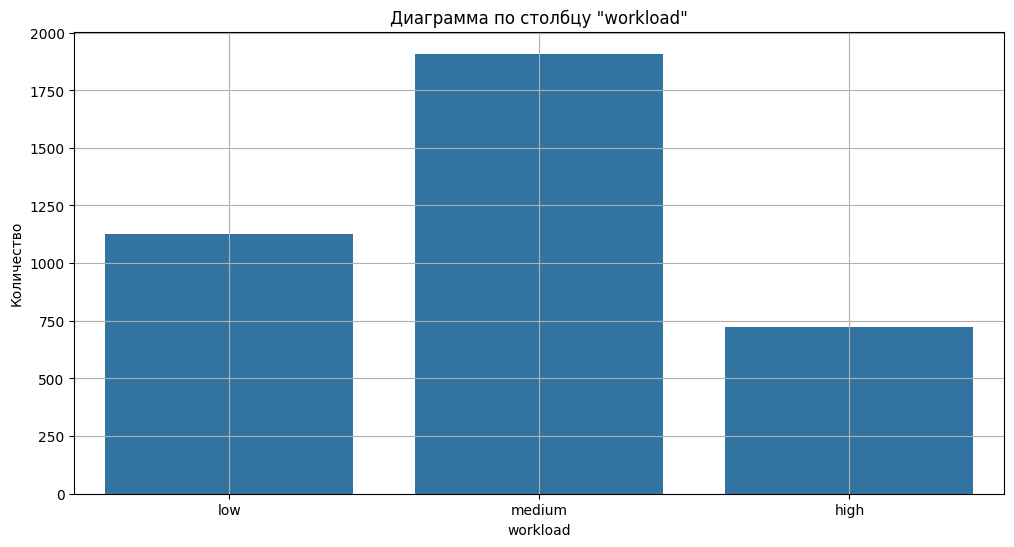

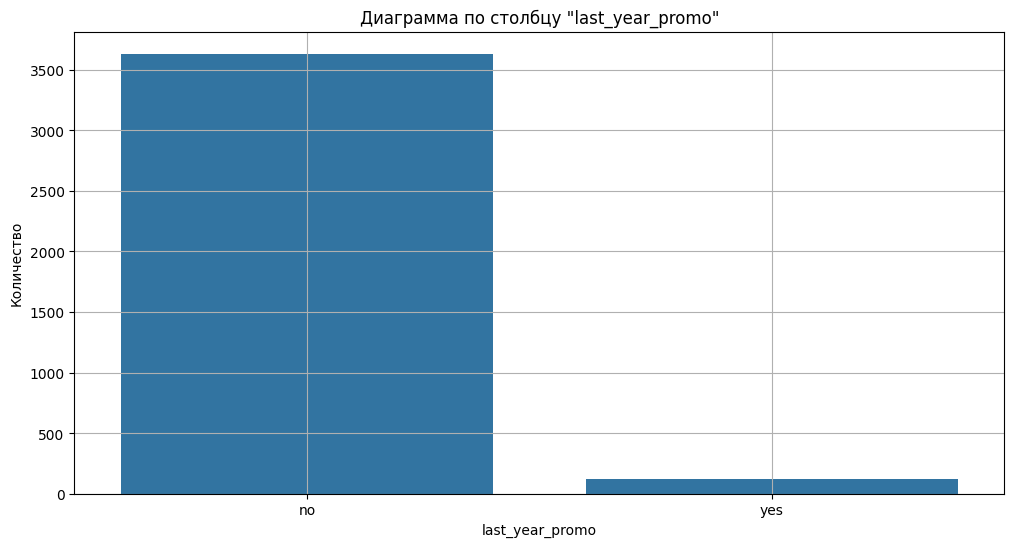

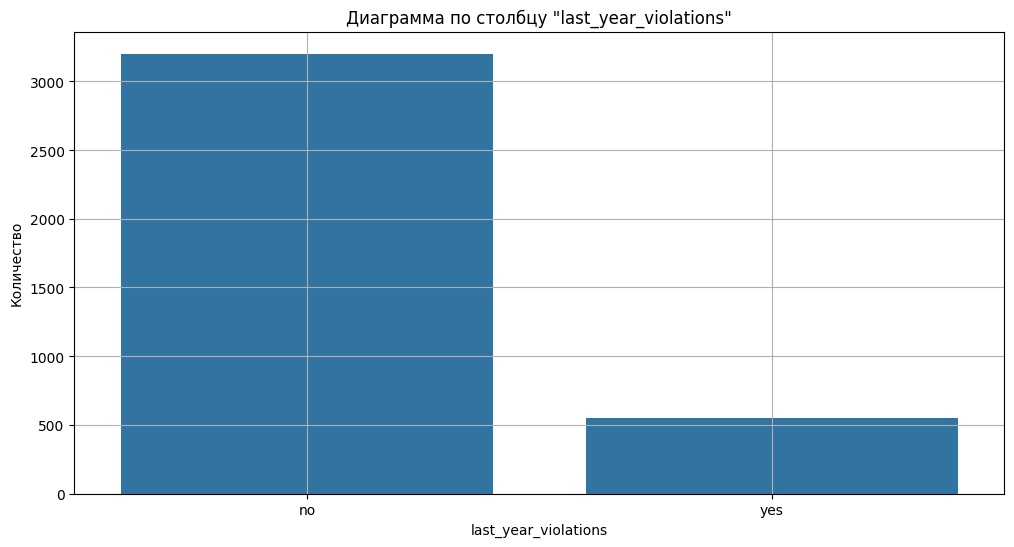

In [32]:
df_hist(dict_1[list_1[0]])

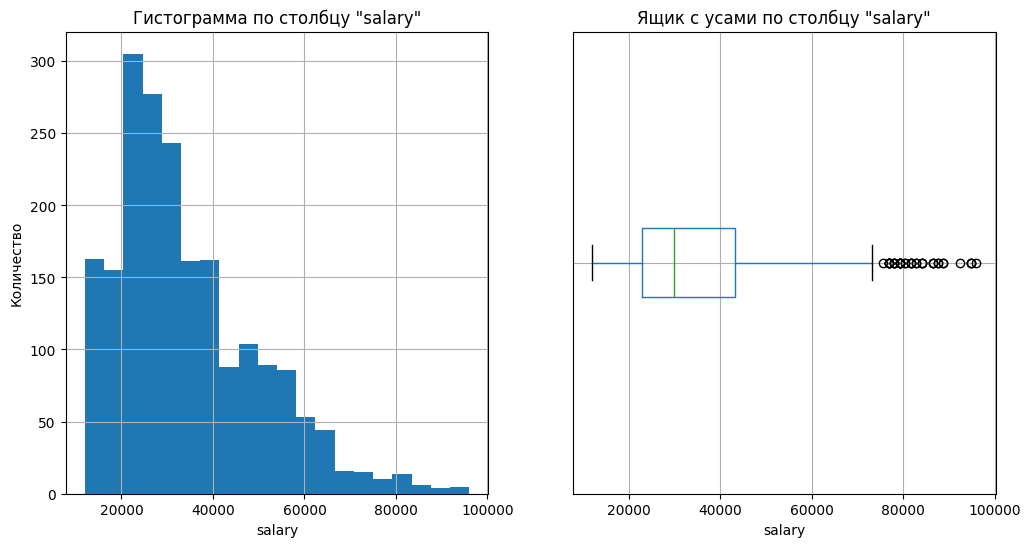

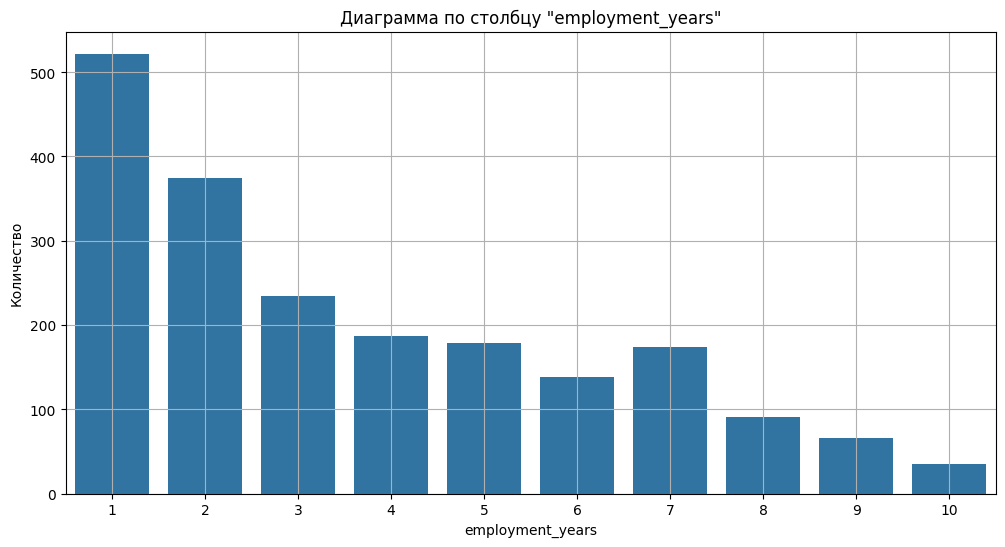

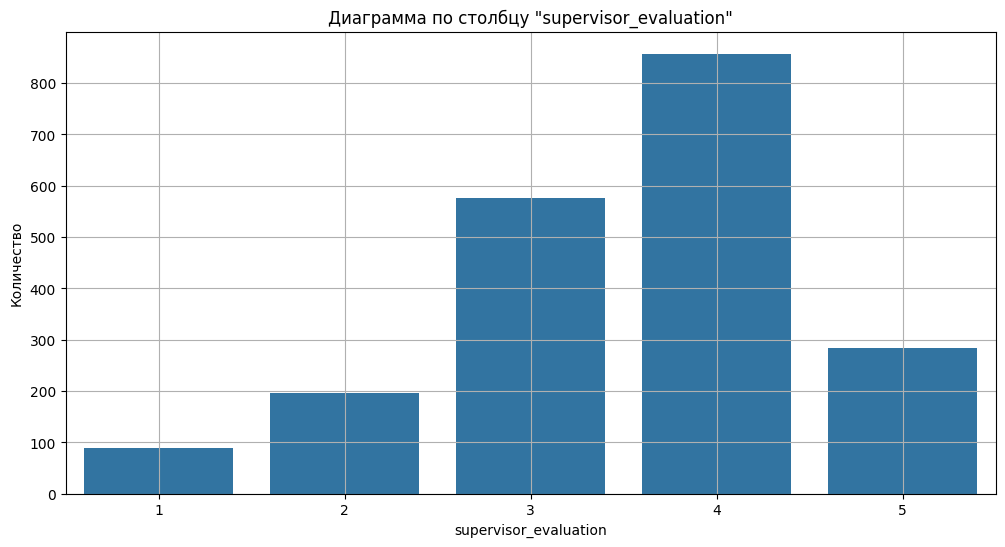

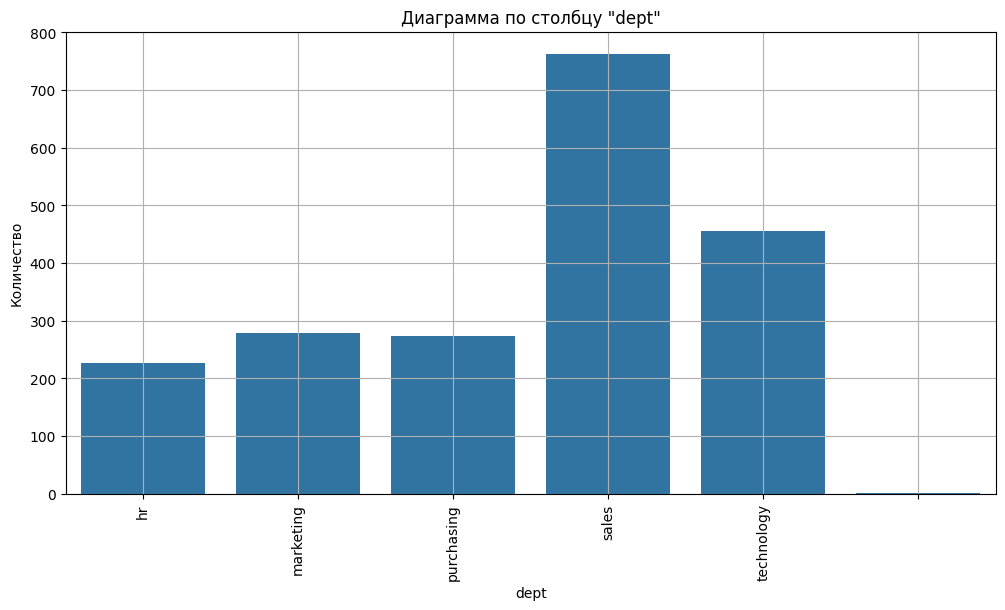

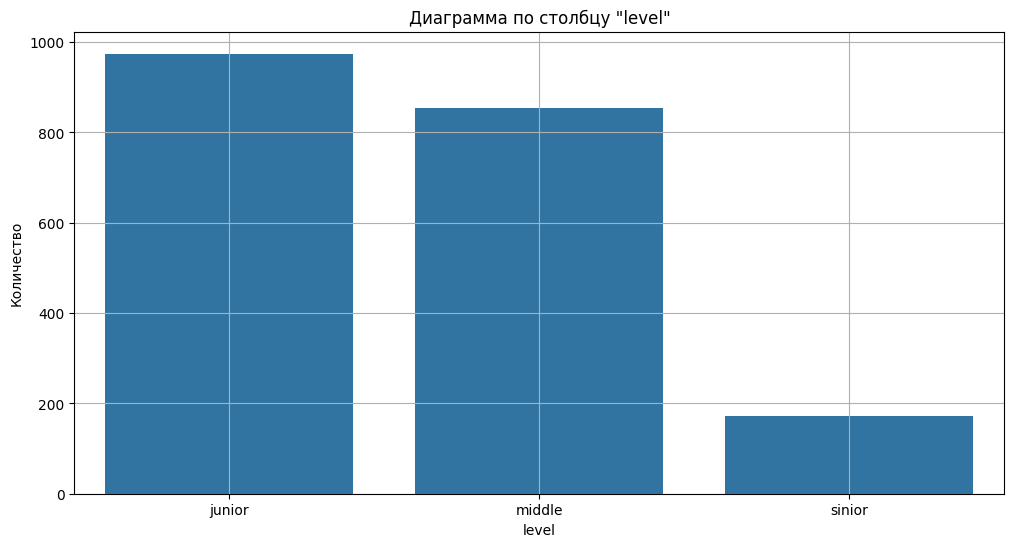

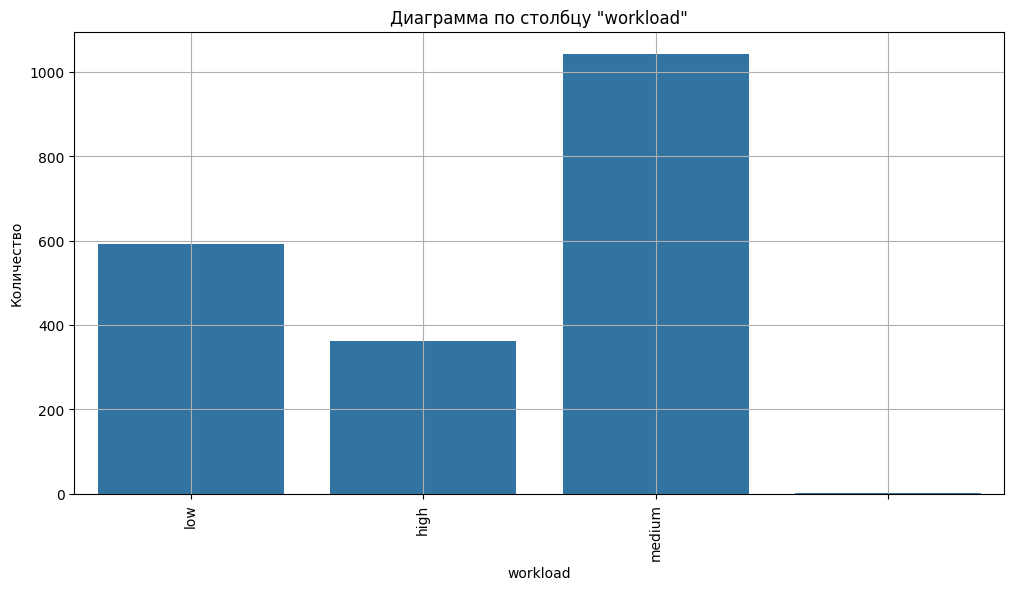

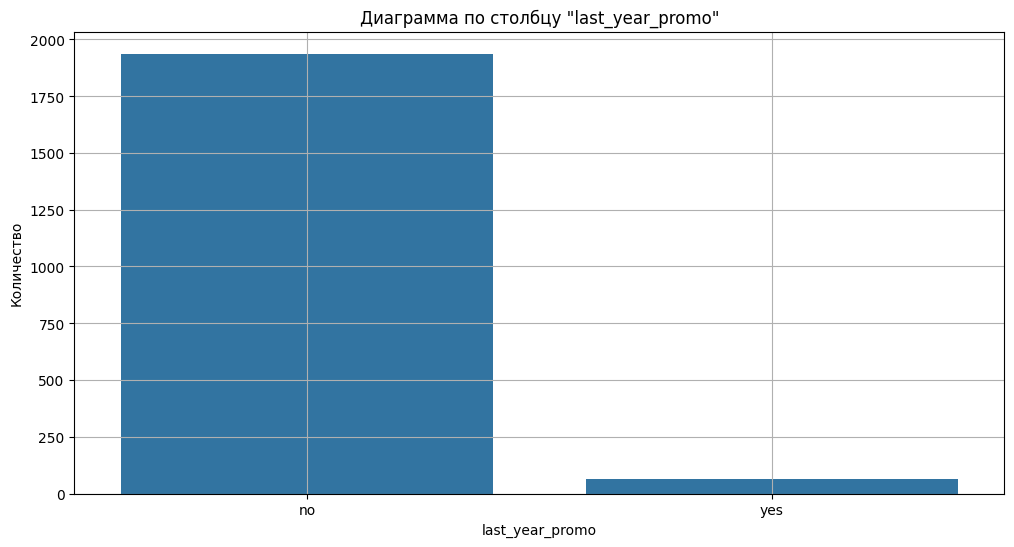

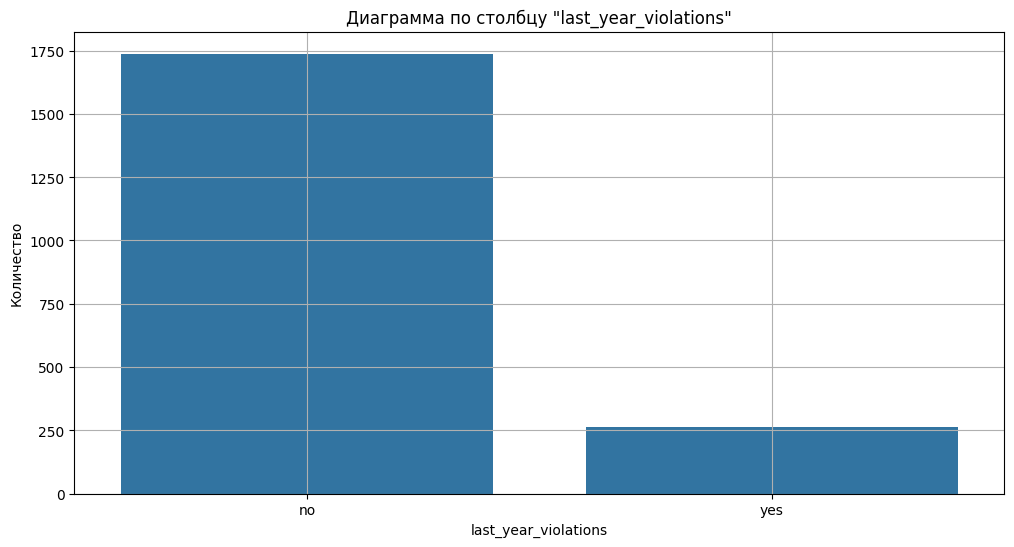

In [33]:
df_hist(dict_1[list_1[1]])

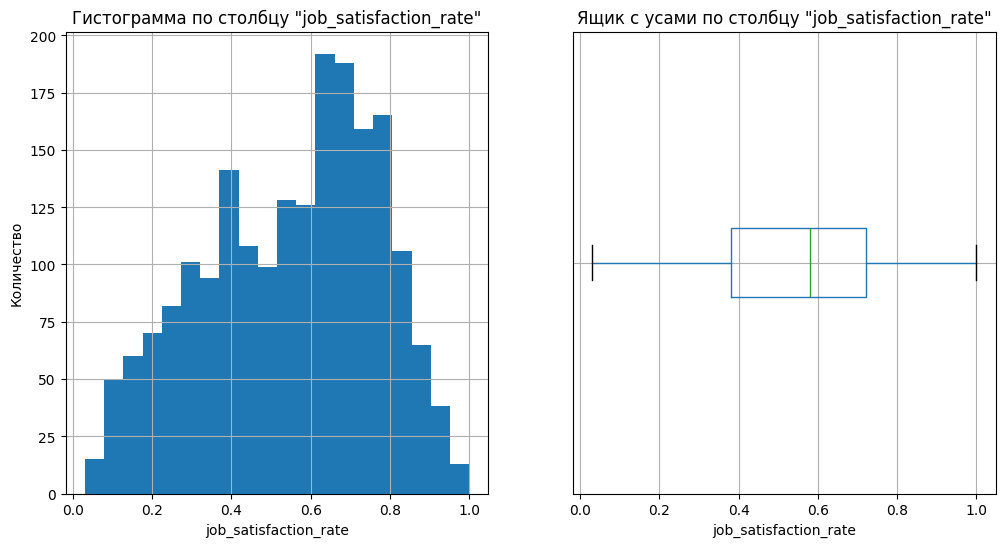

In [34]:
df_hist(dict_1[list_1[2]])

#### Корреляционный анализ

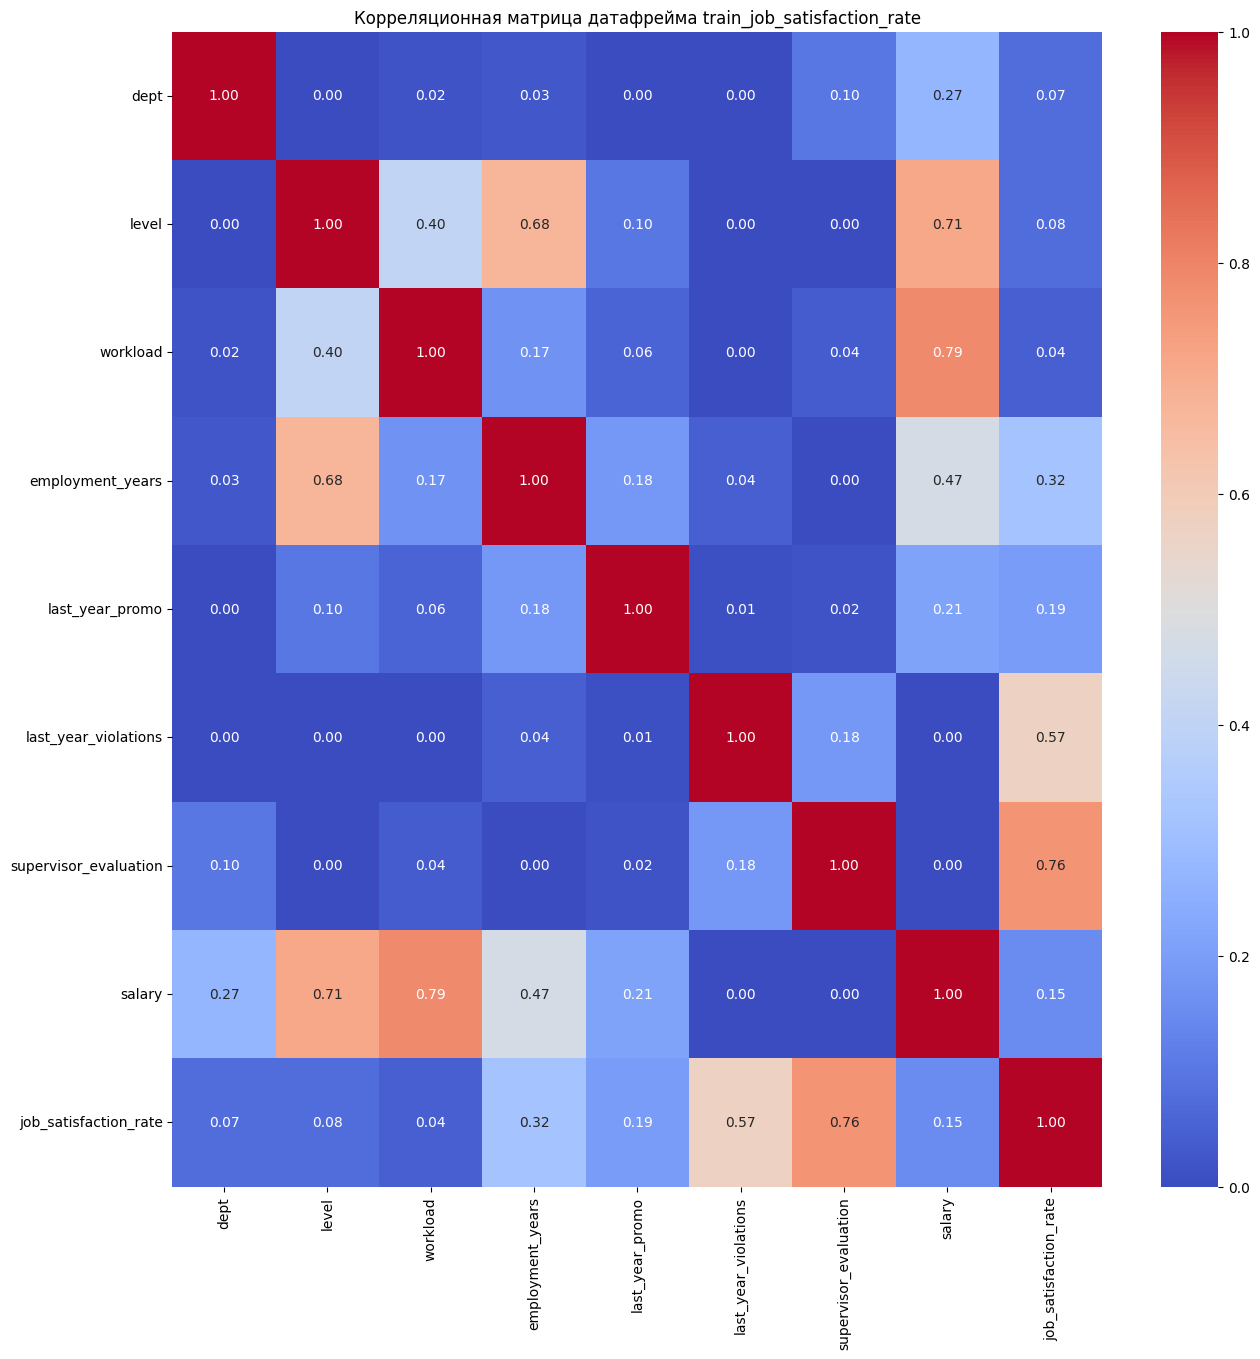

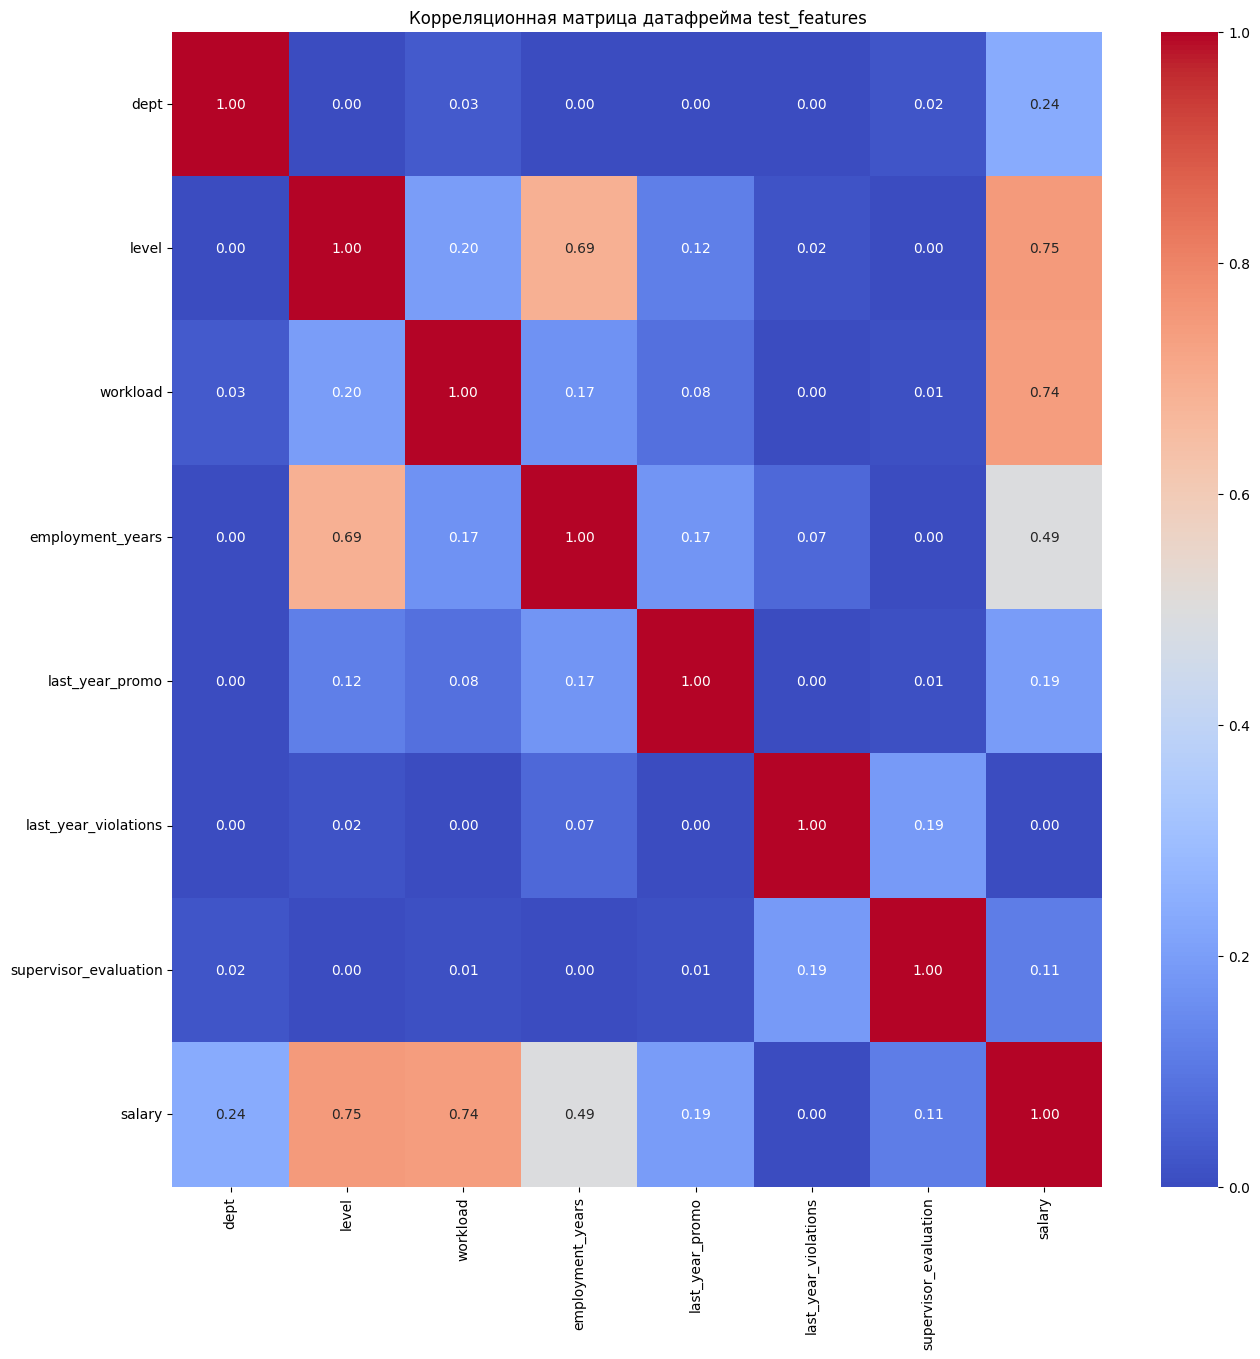

In [35]:
df_corr(dict_1, continuous_features=['salary', 'job_satisfaction_rate'])

#### Промежуточный вывод

Исследовательский анализ не выявил выбросы и аномалии в данных.
Также в ходе корреляционного анализа не было выявлено мультикорреляции признаков.

Количественные признаки показывают распределение Пуассона и нормальное распределение.

Большее количество работников получает зарплату от 10 до 50 тысяч. Также большее количество сотрудников имеет стаж работы до 5 лет, и оценку сепервайзера 3-4. Большее количество сотрудников работает в sales. Большее количество сотрудников имеют уровень должности junior и middle. Также большинство сотрудников имеют загруженность medium. Также за прошлый год малое количество сотрудников получило повышение или предупреждение о нарушении


<a id='#4-distinct'></a>
### Шаг 4. Подготовка данных
Подготовку признаков выполните в пайплайне, дополнив пайплайн шагом предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

In [36]:
dict_1.keys()

dict_keys(['train_job_satisfaction_rate', 'test_features', 'test_target_job_satisfaction_rate'])

In [37]:
X_train = dict_1[list_1[0]].drop(columns=['job_satisfaction_rate'])
y_train = dict_1[list_1[0]]['job_satisfaction_rate']
X_test = dict_1[list_1[1]]
y_test = dict_1[list_1[2]]


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3755, 8), (3755,), (2000, 8), (2000, 1))

In [38]:
# создаём списки с названиями признаков
cat_columns = X_train.select_dtypes('object').columns.tolist()
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = X_train.select_dtypes('number').columns.tolist()

ord_categories = [['junior', 'middle', 'sinior'],
                  ['low','medium','high']]


In [39]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', 
                           handle_unknown='infrequent_if_exist',
                           sparse_output=False 
                           )),
     ('simpleImputer_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
    )


# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=ord_categories, 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
     ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)


# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)


# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    # ('poly_features', PolynomialFeatures(degree=2, order='C')),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])


#### Промежуточный вывод

Пайплайн для обучения моделей МО подготовлен. Подготовка данных включена в пайплайн

<a id='#5-distinct'></a>
### Шаг 5. Обучение моделей
Обучите как минимум две модели. Возьмите одну линейную модель, а в качестве второй — дерево решений. Подберите гиперпараметры как минимум для одной модели с помощью одного из известных вам инструментов.

Выберите лучшую модель и проверьте её качество. Выбор делайте на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»).

Напишите функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE. Используйте эту метрику при подборе гиперпараметров и оценке качества моделей. 

Критерий успеха: SMAPE ≤15 на тестовой выборке.

В решении сохраните работу со всеми моделями, которые вы пробовали. Сделайте выводы.

In [40]:
param_grid_linear = [
    # словарь для модели KNeighborsRegressor() 
    {
        'models': [KNeighborsRegressor(n_jobs=-1)],
        'models__n_neighbors': range(2,15,2),
        # 'feature_selection__k': range(5, 12),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели SVR()
    {
        'models': [SVR()],
        'models__C': range(1,22,5),
        'models__kernel': ['linear', 'rbf', 'sigmoid'],
        'feature_selection__k': range(5, 12, 2),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },

    # Словарь для модели LinearRegression()
    {
        'models': [LinearRegression(n_jobs=-1)],
        # 'feature_selection__k': range(5, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [41]:
randomized_search_linear = df_randomized_search_regressor(pipe_final, param_grid_linear)

In [42]:
%%time
randomized_search_linear.fit(X_train, y_train)

print(F'Метрика SMAPE: {randomized_search_linear.best_score_}')
print('Лучшая модель и её параметры:\n\n')
randomized_search_linear.best_estimator_

Метрика SMAPE: -14.729548408465197
Лучшая модель и её параметры:


CPU times: total: 24.2 s
Wall time: 24.6 s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'sinior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary'])])),
                ('feature_selection', SelectKBest(k=11)),
                ('models', SVR(C=1))])

Предварительный расчет показал преимущество модели SVR.

#### KNN

#### SVR

#### Дерево решений DecisionTreeRegressor

In [43]:
param_grid_tree = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2,10),
        'models__max_features': range(2,10),
        'models__min_samples_split':range(1,20,2),
        'models__min_samples_leaf':range(1,20,2),
        'feature_selection__k': range(5, 15, 2),
        # 'feature_selection__score_func': [f_classif, mutual_info_classif],
        # 'poly_features__include_bias': [False],
        # 'poly_features__interaction_only':[False,True],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [44]:
randomized_search_tree = df_randomized_search_regressor(pipe_final, param_grid_tree, n_iter=20)

In [45]:
%%time
randomized_search_tree.fit(X_train, y_train)

print(F'Метрика SMAPE: {randomized_search_tree.best_score_}')
print('Лучшая модель и её параметры:\n\n')
randomized_search_tree.best_estimator_

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=13 is greater than n_featu

Метрика SMAPE: -18.027297336156618
Лучшая модель и её параметры:


CPU times: total: 6.86 s
Wall time: 7.04 s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', 'passthrough',
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary'])])),
                ('feature_selection', SelectKBest(k=13)),
                ('models',
                 DecisionTreeRegressor(max_depth=9, max_features=7,
                                       min_samples_leaf=15,
                                       min_samples_split=13,
                                       random_state=57))])

#### LinearRegressor

#### Выбор лучшей модели

In [46]:
randomized_search_linear.best_score_

-14.729548408465197

In [47]:
randomized_search_tree.best_score_

-18.027297336156618

In [48]:
if randomized_search_linear.best_score_ > randomized_search_tree.best_score_:
    best_model_1 = randomized_search_linear.best_estimator_
else:
    best_model_1 = randomized_search_tree.best_estimator_
print('Лучшая модель:')
best_model_1

Лучшая модель:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'sinior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary'])])),
                ('feature_selection', SelectKBest(k=11)),
                ('models', SVR(C=1))])

In [49]:
show_metrics_regressor(best_model_1, X_test, y_test)

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,SMAPE,R2,MAE,MSE,RMSE
На тестовой выборке,13.831,0.885,0.06,0.006,0.075


<a id='#6-distinct'></a>
### Шаг 6. Оформление выводов
Лучше всего справилась модель SVR с метрикой SMAPE на тестовой выборке 13.8, что соответствует условию заданий. Гиперпараметры модели:
- С=1

Дополнительно для улучшения метрик и для избежания переобучения модели в пайплайн был внедрен SelectKBest (k=11)

## Задача 2: предсказание увольнения сотрудника из компании
Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

<a id='#1-bullet'></a>
### Шаг 1. Загрузка данных

Загрузите данные из файлов:

Тренировочная выборка:
- train_quit.csv

Входные признаки тестовой выборки те же, что и в прошлой задаче:
- test_features.csv

Целевой признак тестовой выборки:
- test_target_quit.csv

In [50]:
try:
    train_quit = pd.read_csv('n2/train_quit.csv', index_col='id').sort_index()
    test_features = pd.read_csv('n2/test_features.csv', index_col='id').sort_index()
    test_target_quit = pd.read_csv('n2/test_target_quit.csv', index_col='id').sort_index()
except:
    train_quit = pd.read_csv('/datasets/train_quit.csv', index_col='id').sort_index()
    test_features = pd.read_csv('/datasets/test_features.csv', index_col='id').sort_index()
    test_target_quit = pd.read_csv('/datasets/test_target_quit.csv', index_col='id').sort_index()

In [51]:
list_2 = ('train_quit', 'test_features', 'test_target_quit')
dict_2 = {'train_quit':train_quit,
               'test_features':test_features,
               'test_target_quit':test_target_quit}

In [52]:
df_info(dict_2)

train_quit
<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 100222 to 999915
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   4000 non-null   object
 1   level                  4000 non-null   object
 2   workload               4000 non-null   object
 3   employment_years       4000 non-null   int64 
 4   last_year_promo        4000 non-null   object
 5   last_year_violations   4000 non-null   object
 6   supervisor_evaluation  4000 non-null   int64 
 7   salary                 4000 non-null   int64 
 8   quit                   4000 non-null   object
dtypes: int64(3), object(6)
memory usage: 312.5+ KB


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
100222,sales,junior,medium,3,no,no,2,20400,yes
100459,purchasing,junior,medium,3,no,no,3,21600,yes
100469,marketing,junior,medium,1,no,no,4,28800,no
100601,technology,middle,high,4,no,no,4,68400,no
100858,sales,junior,medium,2,no,no,4,25200,yes


----------------------------------------------------


test_features
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


----------------------------------------------------


test_target_quit
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   quit    2000 non-null   object
dtypes: object(1)
memory usage: 31.2+ KB


,quit
id,
100298,no
100480,no
100503,no
100610,no
100692,no


----------------------------------------------------




<a id='#2-bullet'></a>
### Шаг 2. Предобработка данных
Изучите данные и при необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

In [53]:
df_pred(dict_2)

train_quit
Явных дубликатов 1413
Максимум пропусков 0
----------------------------------------------------


test_features
Явных дубликатов 557
Максимум пропусков 2
----------------------------------------------------


test_target_quit
Явных дубликатов 1998
Максимум пропусков 0
----------------------------------------------------




В тренировочной выборке найдено много дубликатов. Избавимся от них

In [54]:
dict_2[list_2[0]] = dict_2[list_2[0]].drop_duplicates()

In [55]:
df_pred(dict_2)

train_quit
Явных дубликатов 0
Максимум пропусков 0
----------------------------------------------------


test_features
Явных дубликатов 557
Максимум пропусков 2
----------------------------------------------------


test_target_quit
Явных дубликатов 1998
Максимум пропусков 0
----------------------------------------------------




In [56]:
df_value(dict_2)

Датафрейм: train_quit




sales         805
technology    581
purchasing    430
marketing     423
hr            348
Name: dept, dtype: int64

middle    1282
junior     958
sinior     347
Name: level, dtype: int64

medium    1244
low        746
high       597
Name: workload, dtype: int64

no     2476
yes     111
Name: last_year_promo, dtype: int64

...

no     1937
yes      63
Name: last_year_promo, dtype: int64

no     1738
yes     262
Name: last_year_violations, dtype: int64



----------------------------------------------------


Датафрейм: test_target_quit




no     1436
yes     564
Name: quit, dtype: int64



----------------------------------------------------




Закодируем в столбце quit данные на

1 - уволился

0 - не уволился

In [57]:
encoder = LabelEncoder()
dict_2[list_2[0]]['quit'] = encoder.fit_transform(dict_2[list_2[0]]['quit'])
dict_2[list_2[2]]['quit'] = encoder.transform(dict_2[list_2[2]]['quit'])

C:\Users\navoh\AppData\Local\Temp\ipykernel_1368\2251189584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dict_2[list_2[0]]['quit'] = encoder.fit_transform(dict_2[list_2[0]]['quit'])


In [58]:
dict_2[list_2[2]]['quit'].tail(5)

id
997290    0
998548    1
998762    1
998900    0
999029    1
Name: quit, dtype: int32

<a id='#3-bullet'></a>
### Шаг 3. Исследовательский анализ данных

3.1. Проведите исследовательский анализ данных.

3.2. Составьте портрет «уволившегося сотрудника». Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

3.3. Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверьте это утверждение: визуализируйте и сравните распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используйте данные с обоими целевыми признаками тестовой выборки.

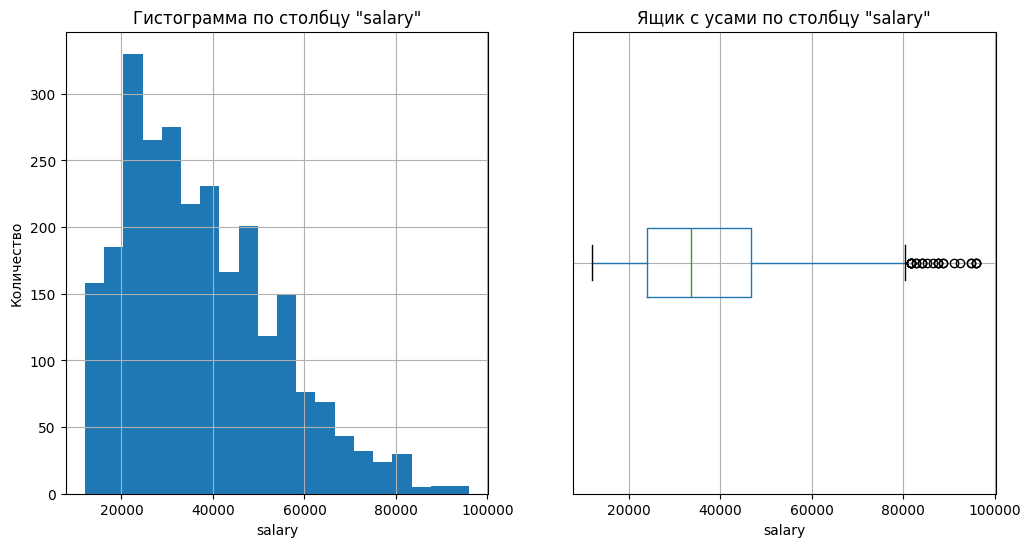

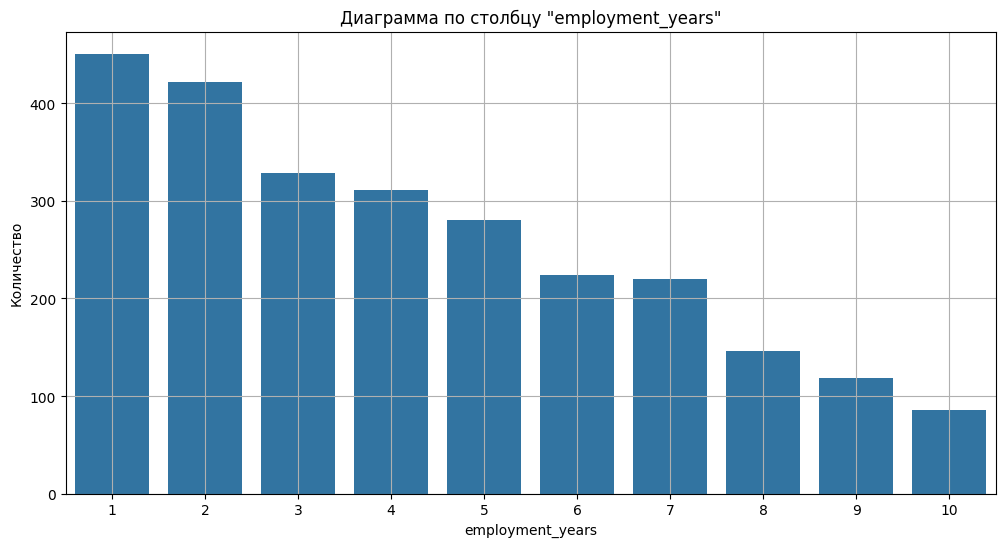

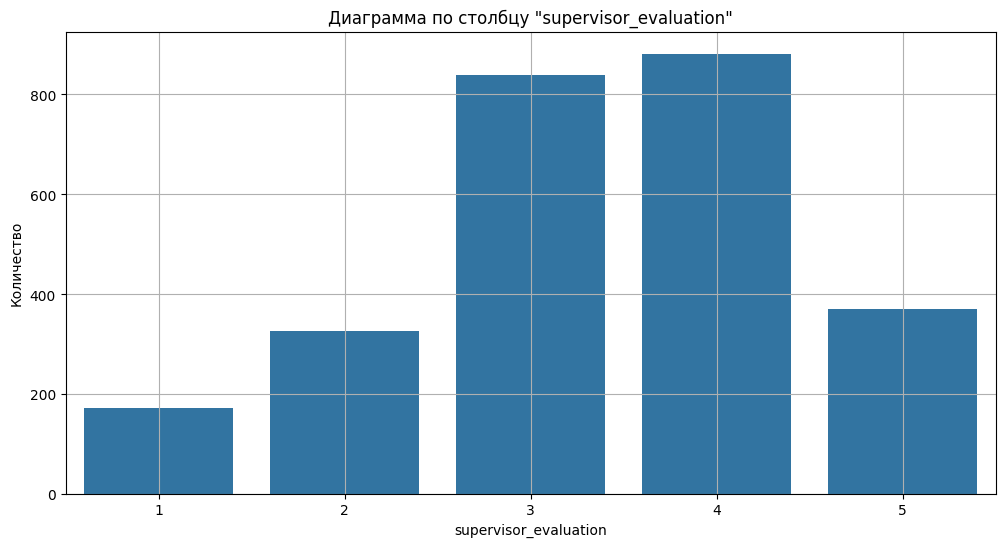

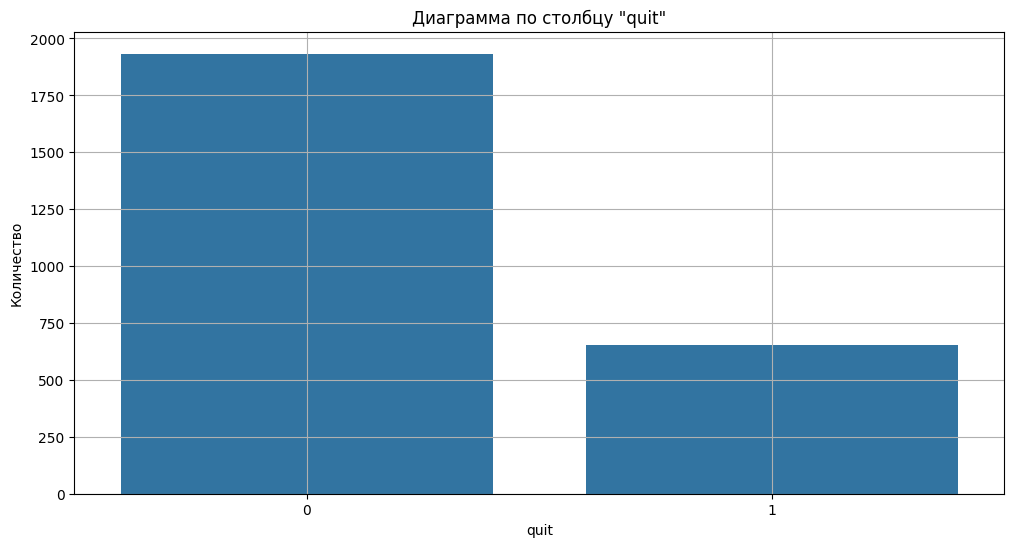

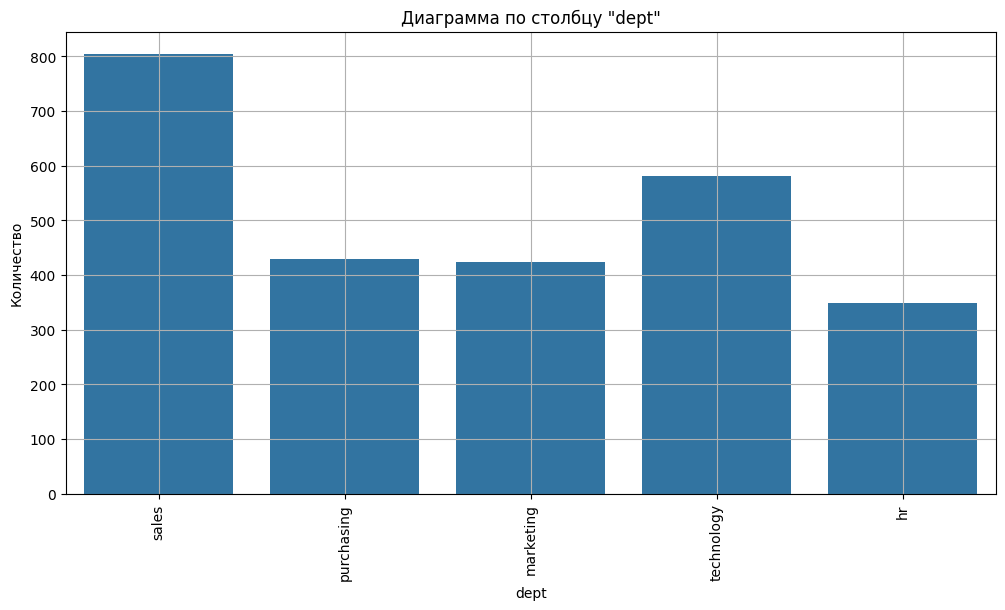

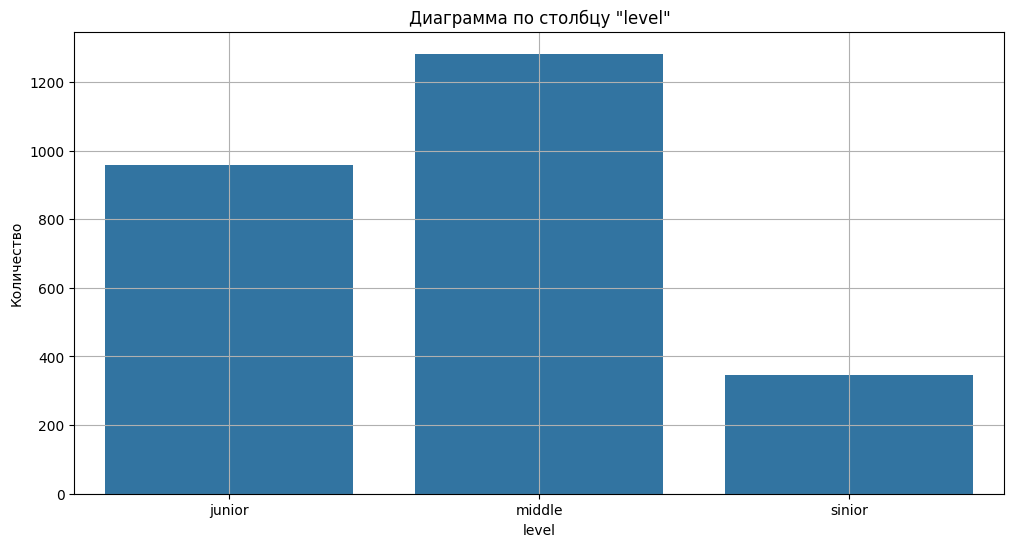

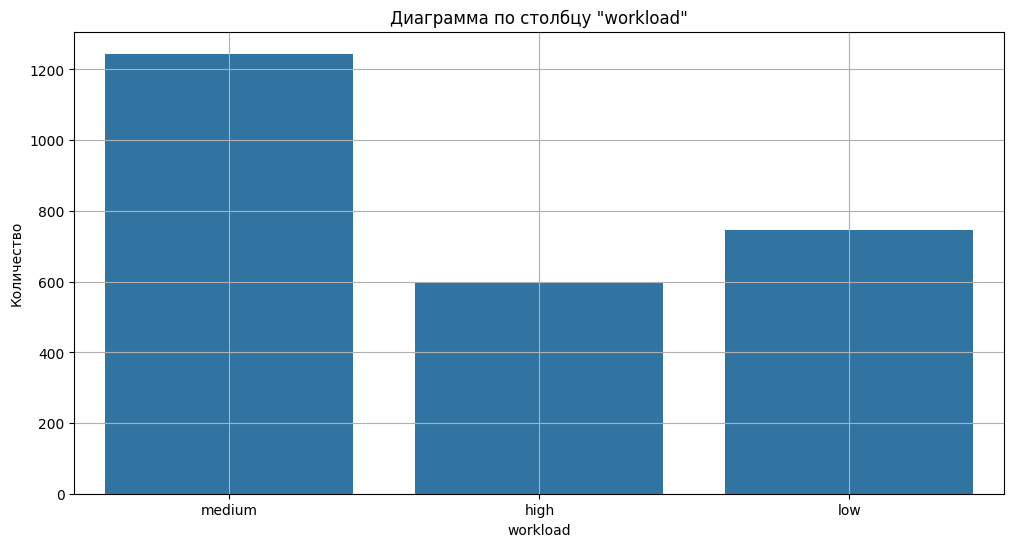

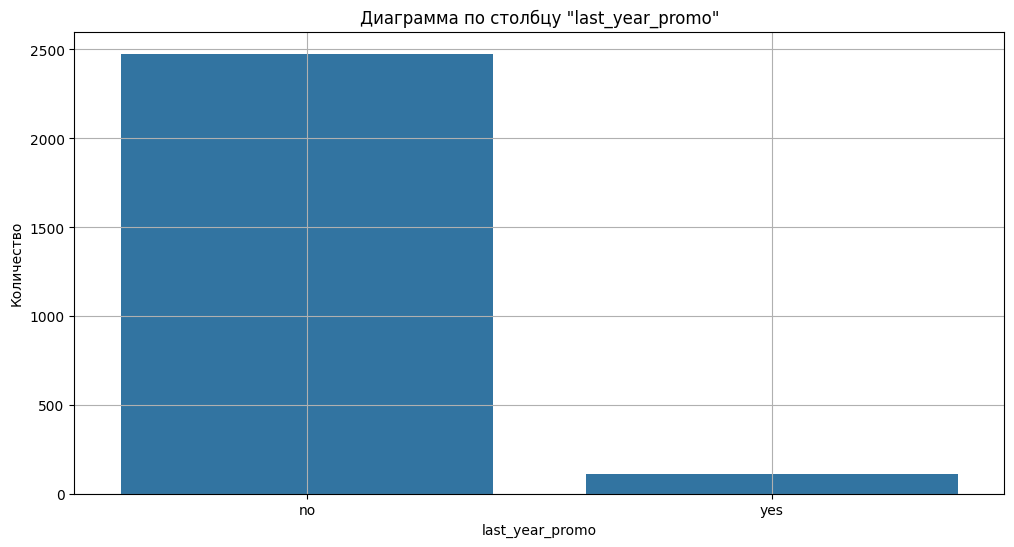

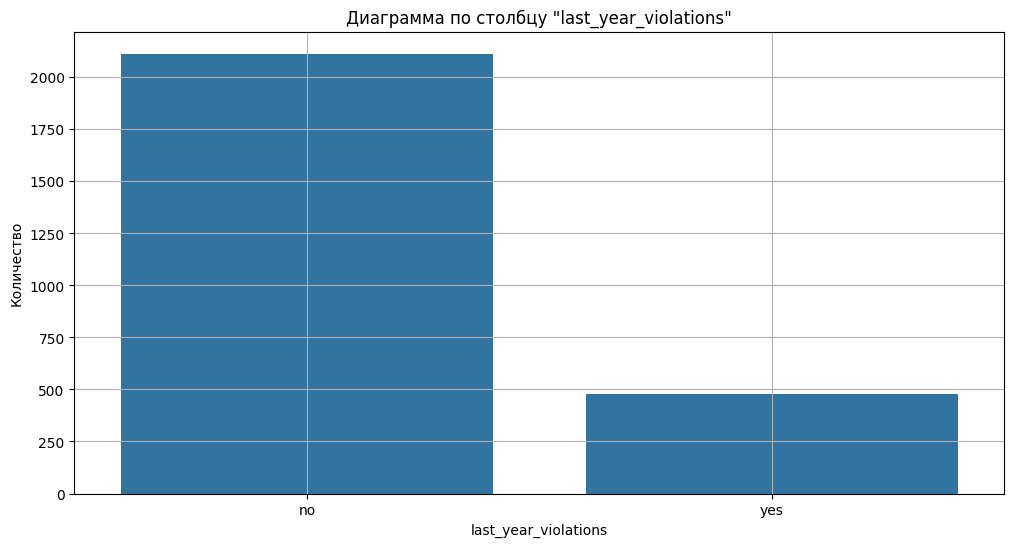

In [59]:
df_hist(dict_2[list_2[0]])

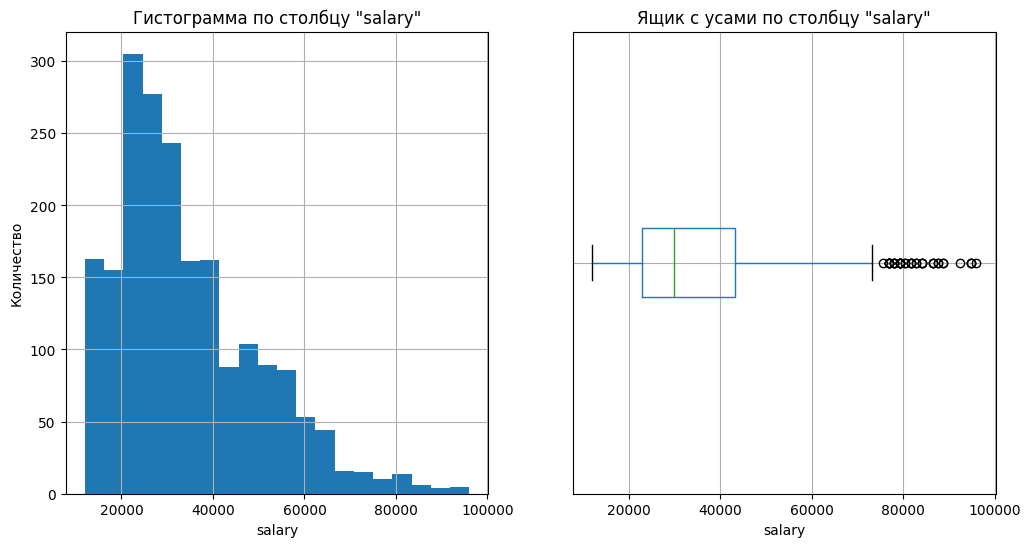

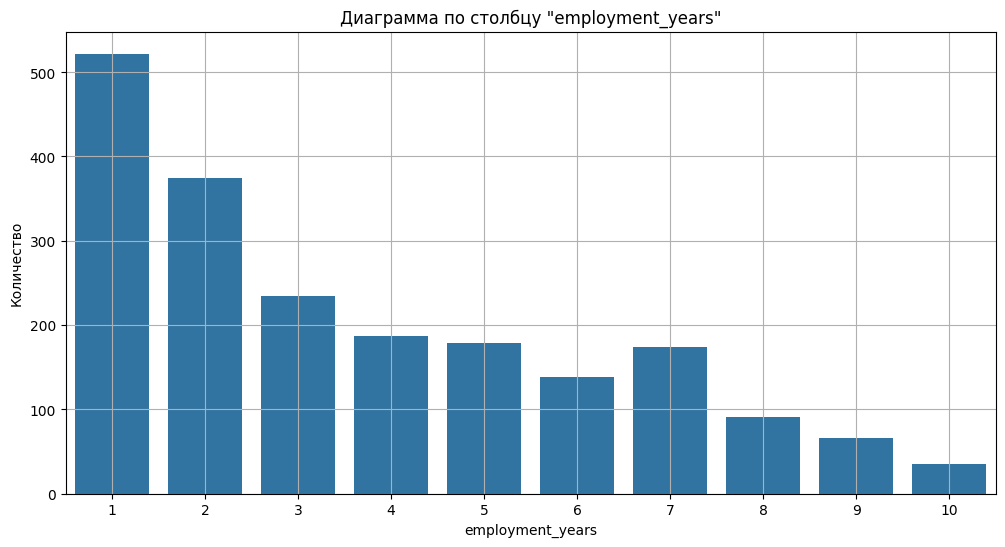

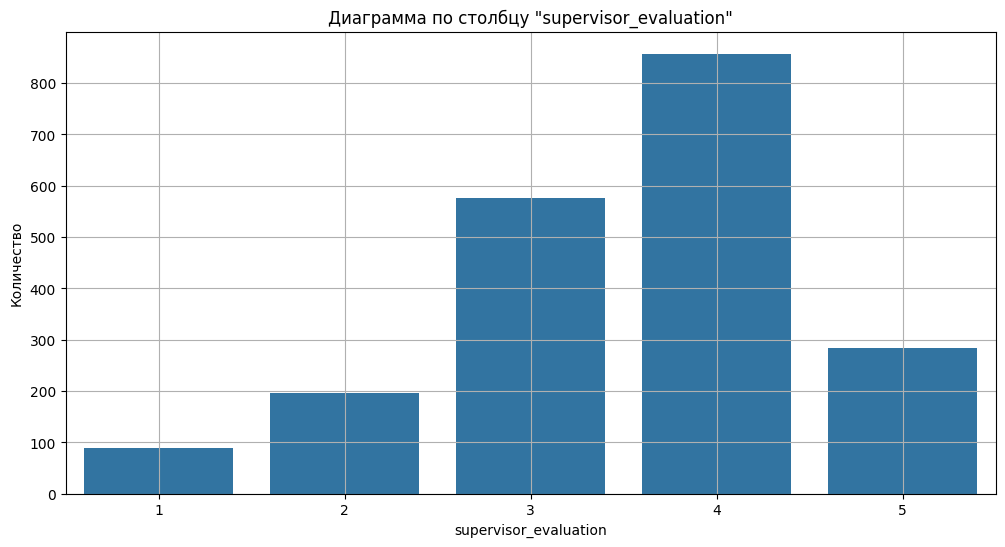

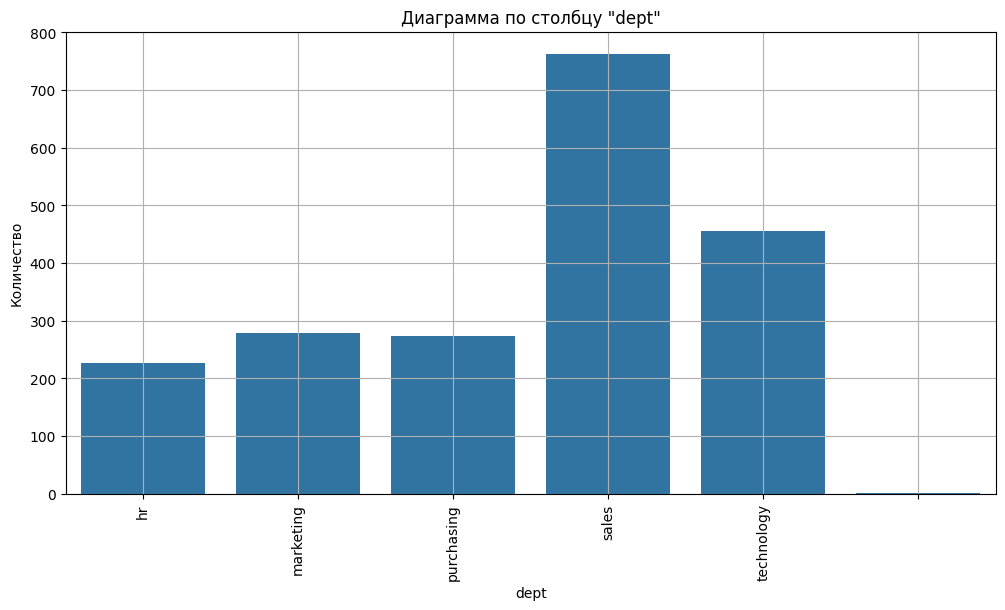

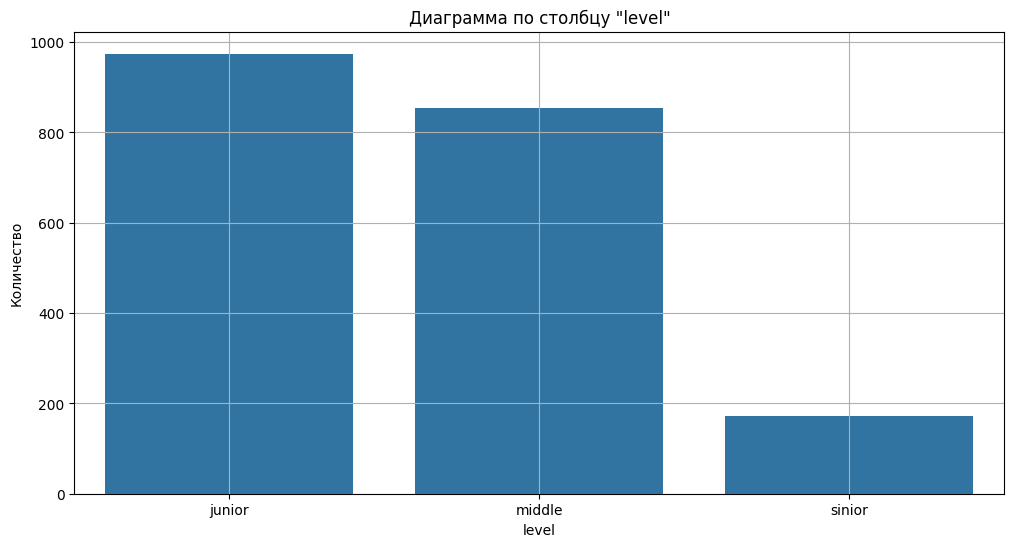

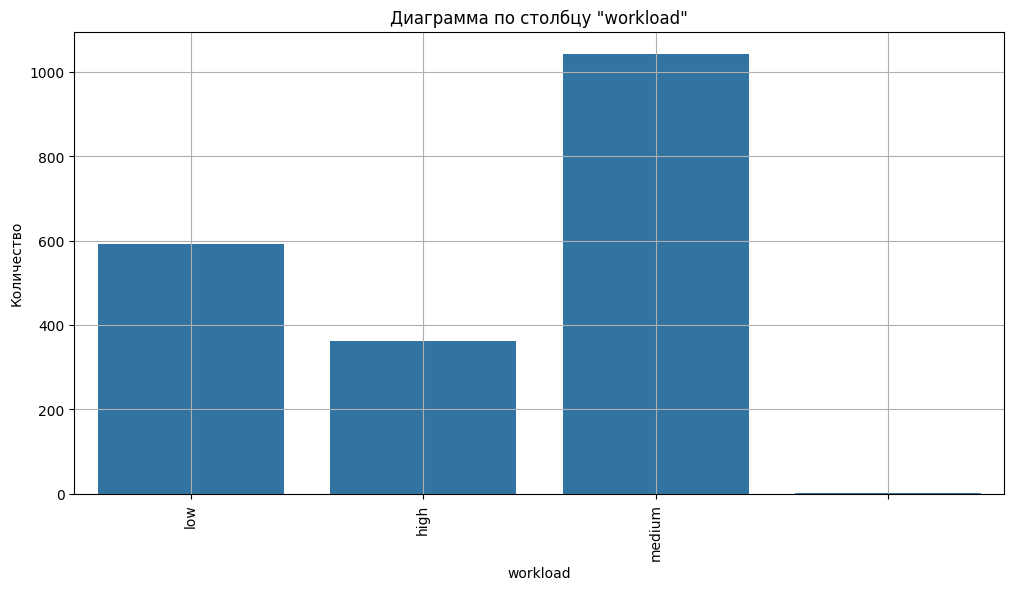

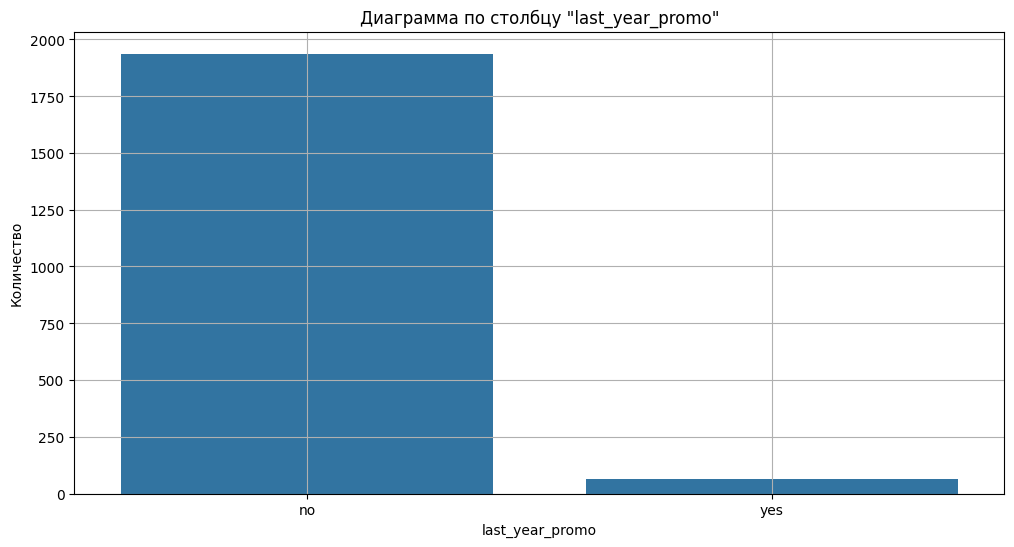

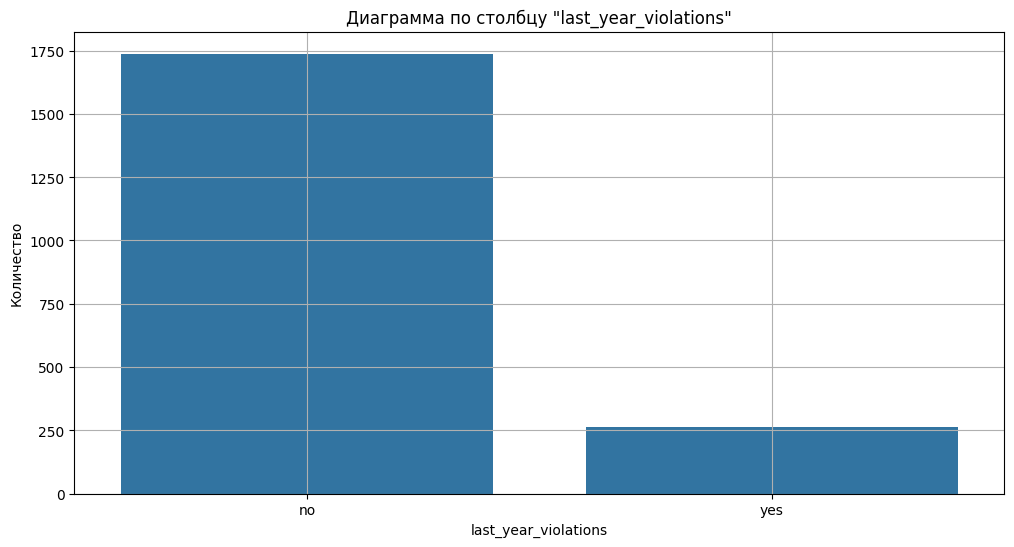

In [60]:
df_hist(dict_2[list_2[1]])

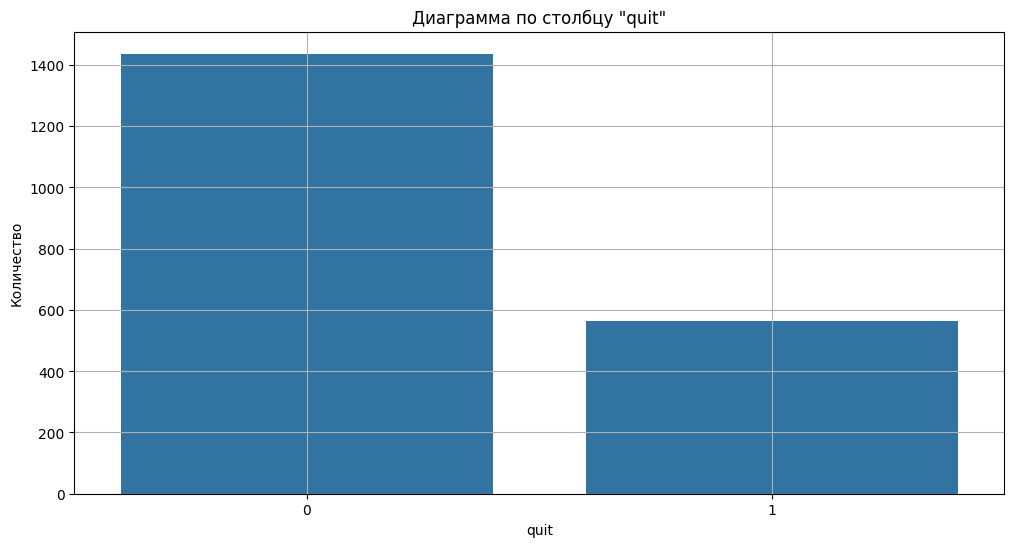

In [61]:
df_hist(dict_2[list_2[2]])

<a id='#3.1-bullet'></a>
#### Портрет уволившегося сотрудника

In [62]:
df_portret = []
if 'job_saatisfaction_rate' in dict_2[list_2[1]].columns:
    df_portret = dict_2[list_2[1]].drop(columns=['job_satisfaction_rate'])
else:
    df_portret = dict_2[list_2[1]]
df_portret = df_portret.join(dict_1[list_1[2]])
df_portret = df_portret.join(dict_2[list_2[2]])
df_portret.head(5)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.80,0
100480,marketing,junior,low,4,no,no,4,16800,0.84,0
100503,purchasing,middle,high,5,no,no,4,55200,0.79,0
100610,sales,middle,medium,5,no,no,4,43200,0.75,0
100692,sales,middle,high,6,no,no,4,48000,0.69,0


In [63]:
df_portret['quit'] = encoder.inverse_transform(df_portret['quit'])

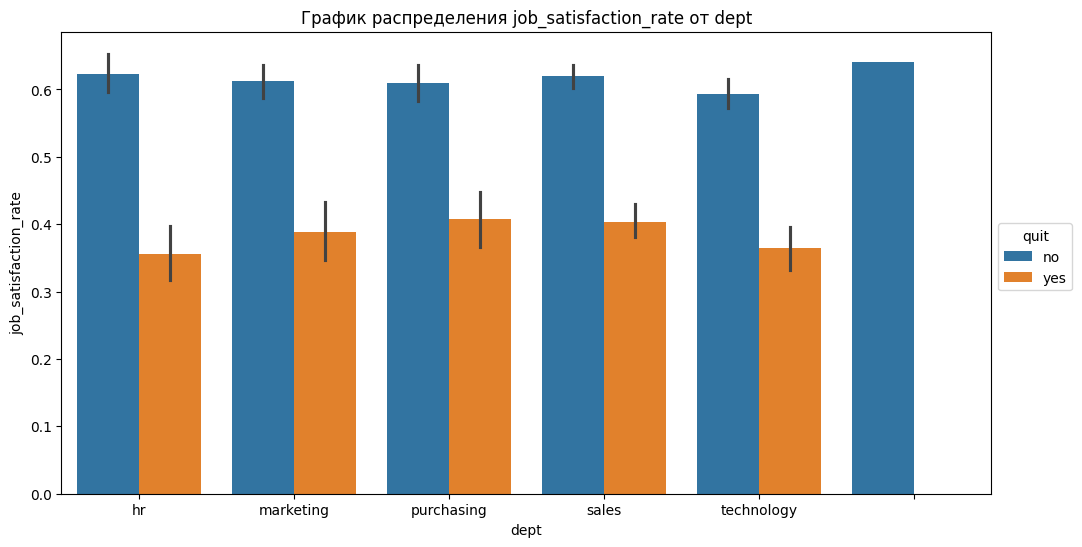

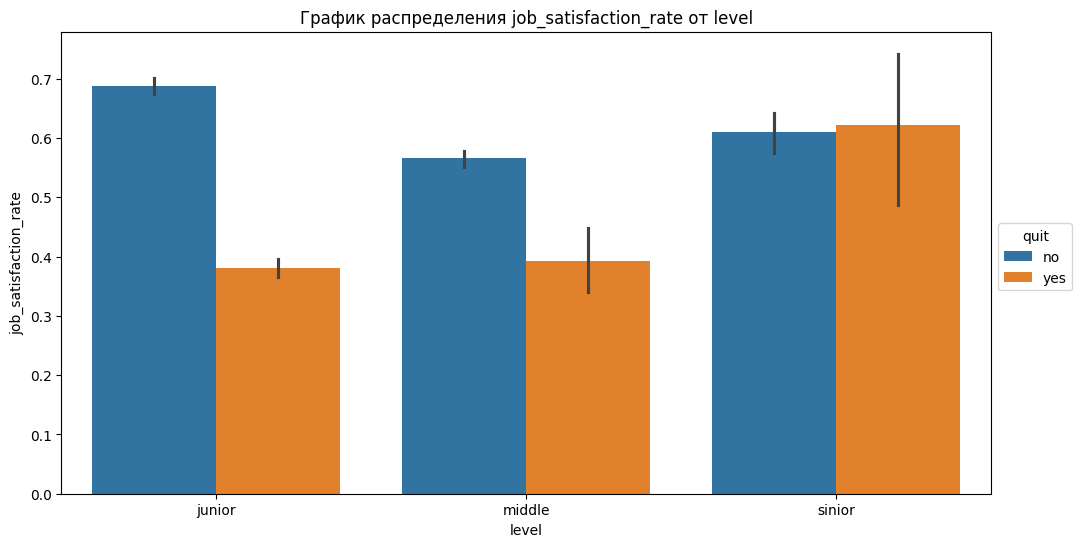

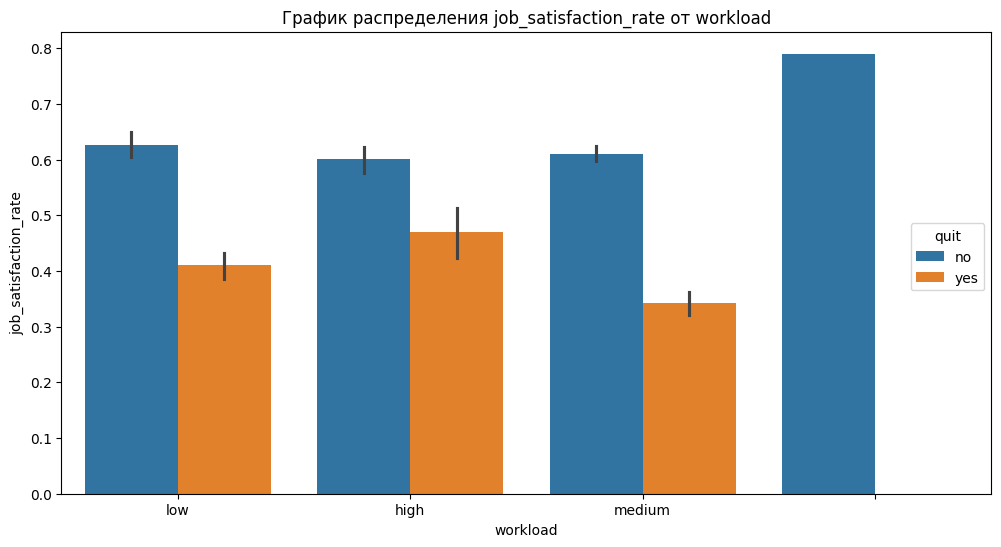

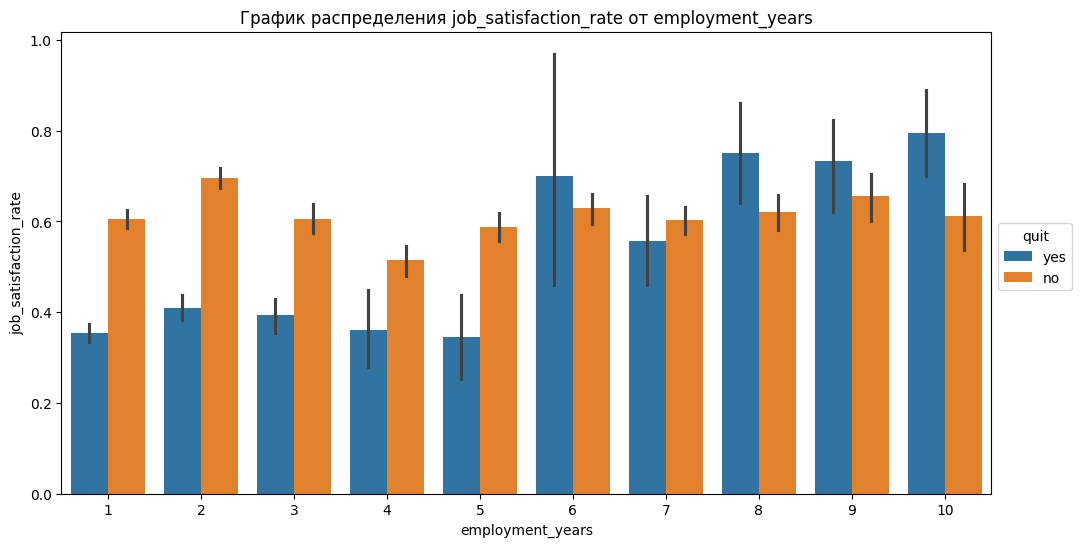

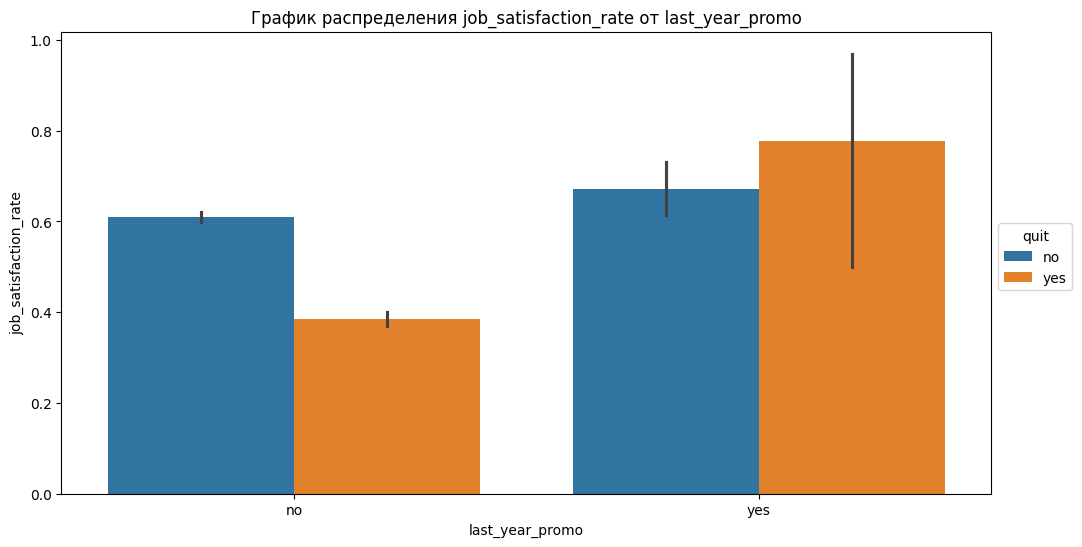

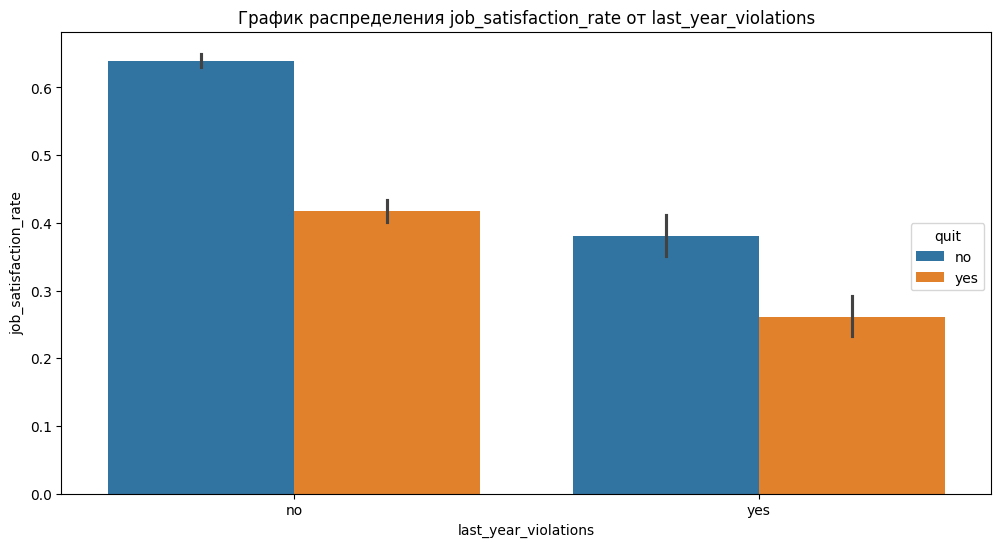

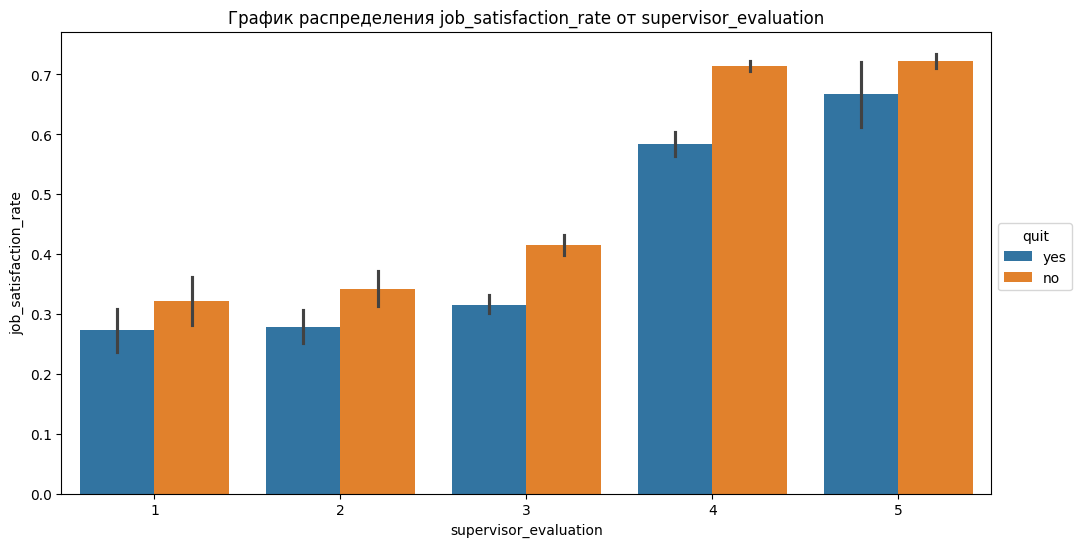

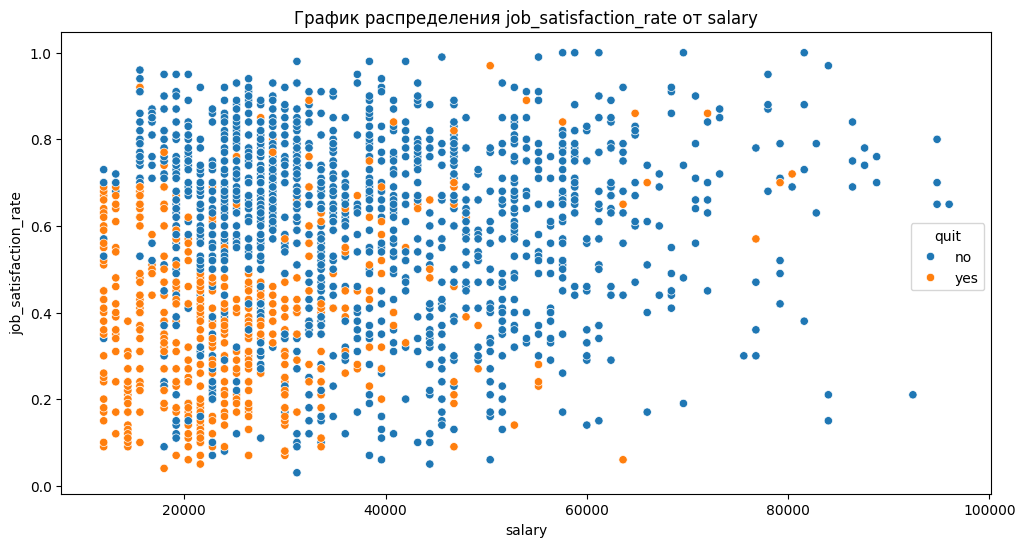

In [103]:
for col in df_portret.columns:
	if col not in ['job_satisfaction_rate', 'quit', 'salary']:
		sns.barplot(x=df_portret[col], 
						y=df_portret['job_satisfaction_rate'], 
						hue=df_portret['quit'],);
		plt.title(f'График распределения job_satisfaction_rate от {col}')
		plt.legend(bbox_to_anchor=(1, 0.6), title='quit')
		plt.show();
	elif col in ['salary']:
		sns.scatterplot(x=df_portret[col], 
						y=df_portret['job_satisfaction_rate'], 
						hue=df_portret['quit'],);
		plt.title(f'График распределения job_satisfaction_rate от {col}')
		plt.legend(bbox_to_anchor=(1, 0.6), title='quit')
		plt.show();

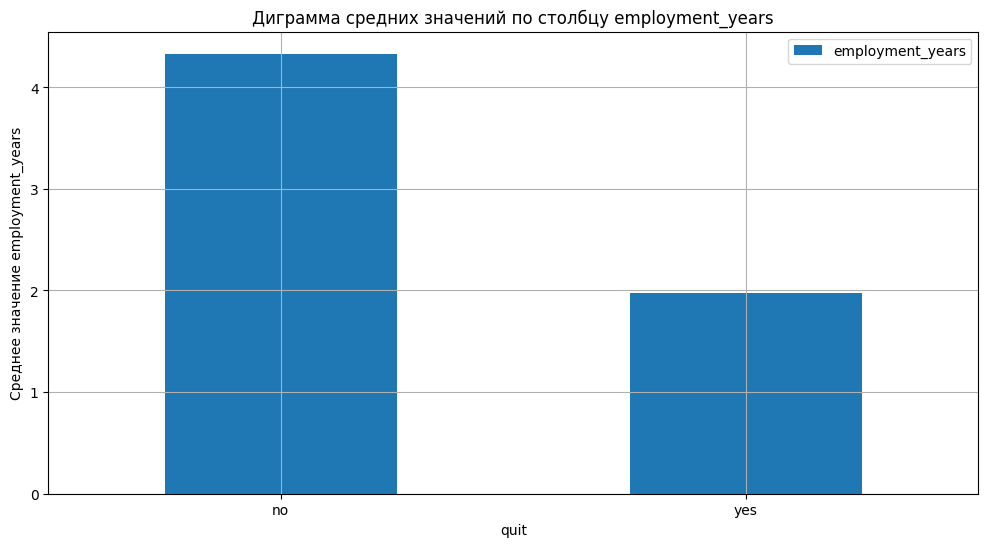

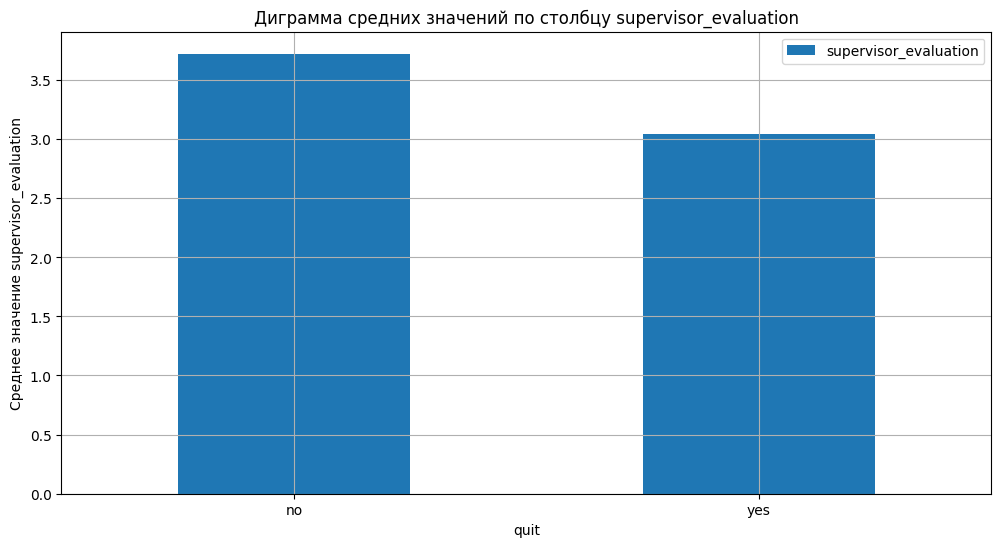

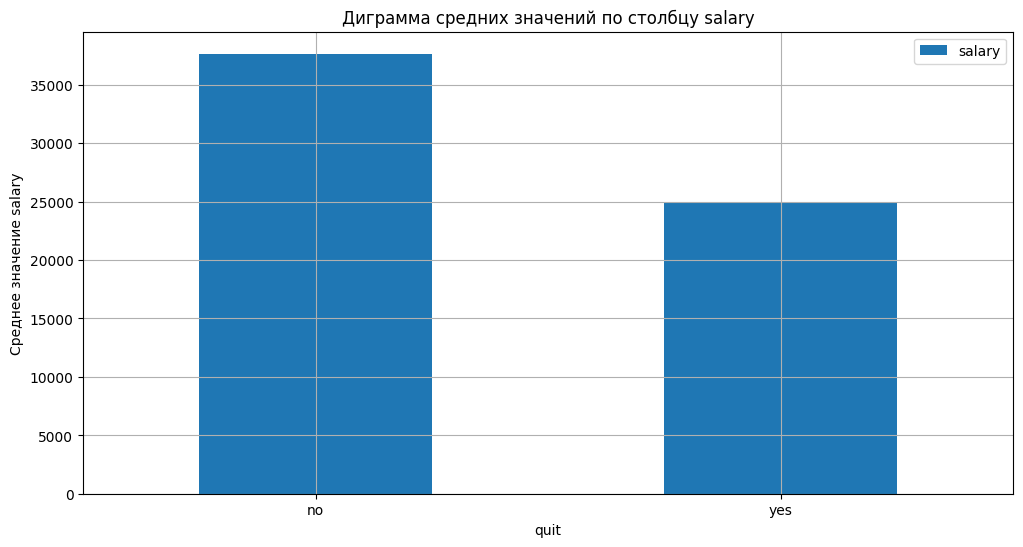

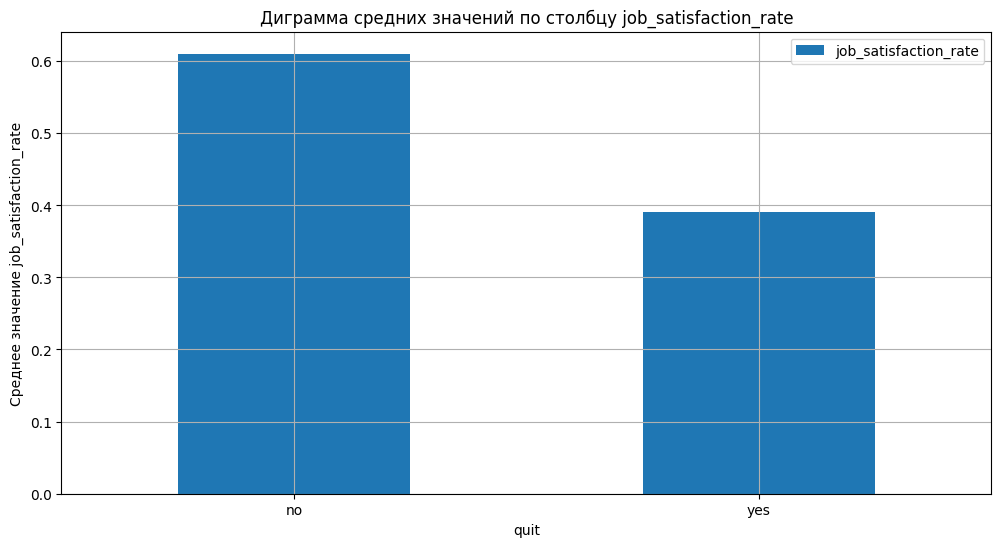

In [64]:
df_portret_num = df_portret.groupby('quit').agg('mean').round(2)
for col in df_portret_num.columns:
    df_portret_num.plot(kind='bar', y=col, grid=True)
    plt.title(f'Диграмма средних значений по столбцу {col}')
    plt.ylabel(f'Среднее значение {col}')
    plt.xticks(rotation=0)
    plt.show()

In [65]:
df_portret_stay = df_portret.loc[df_portret['quit'] == 'no'].drop(columns=['quit'])
df_portret_quit = df_portret.loc[df_portret['quit'] == 'yes'].drop(columns=['quit'])

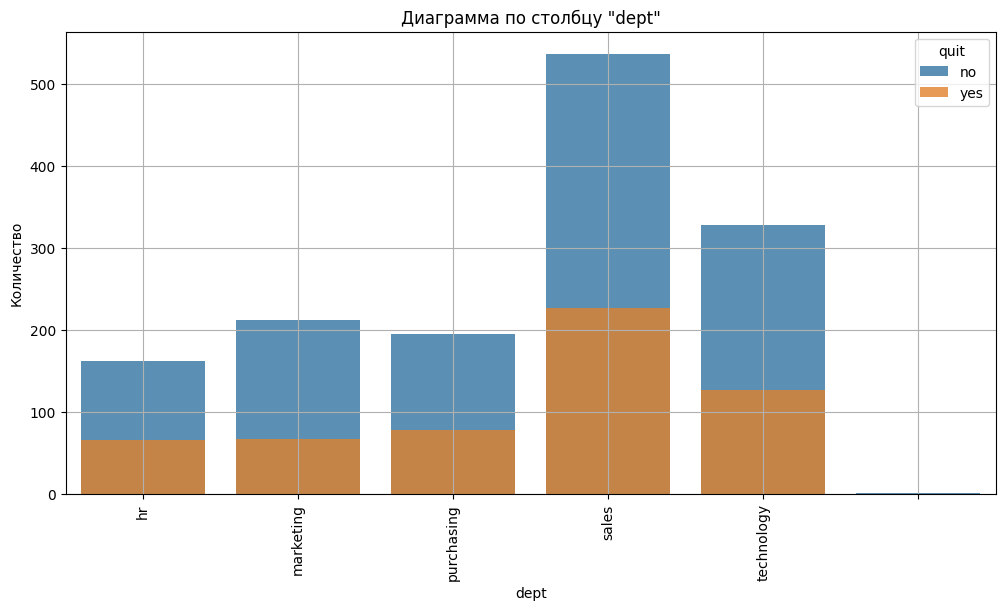

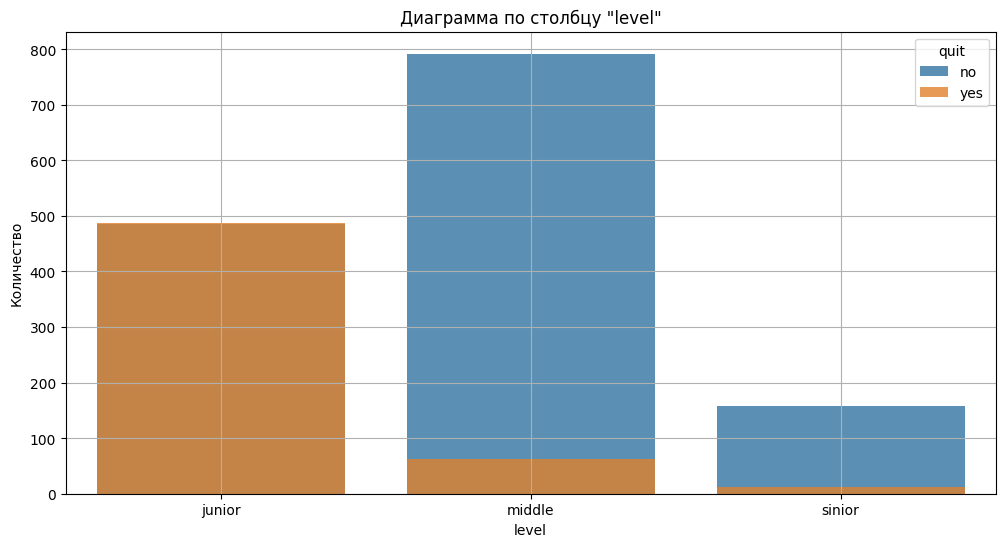

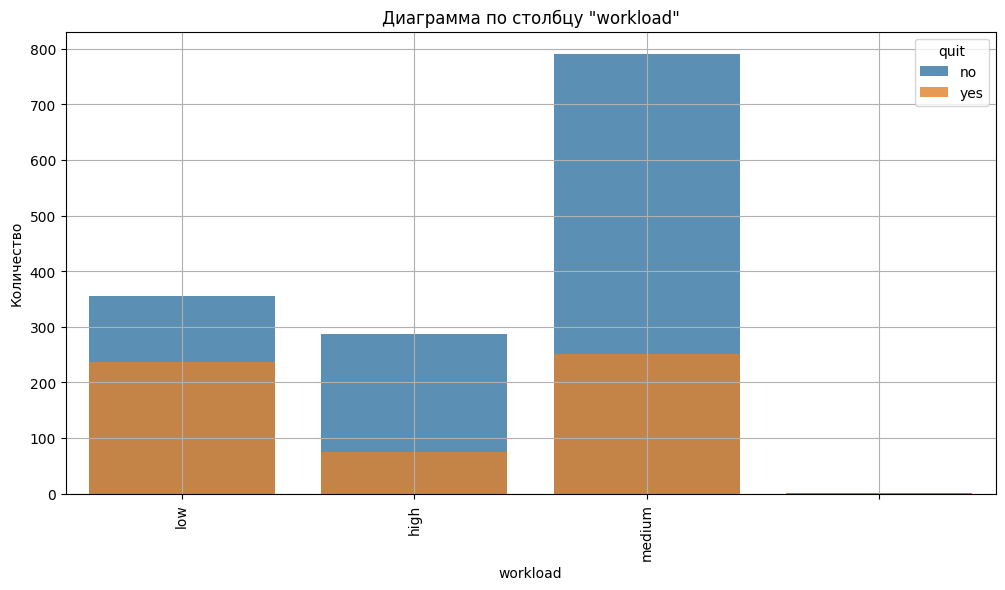

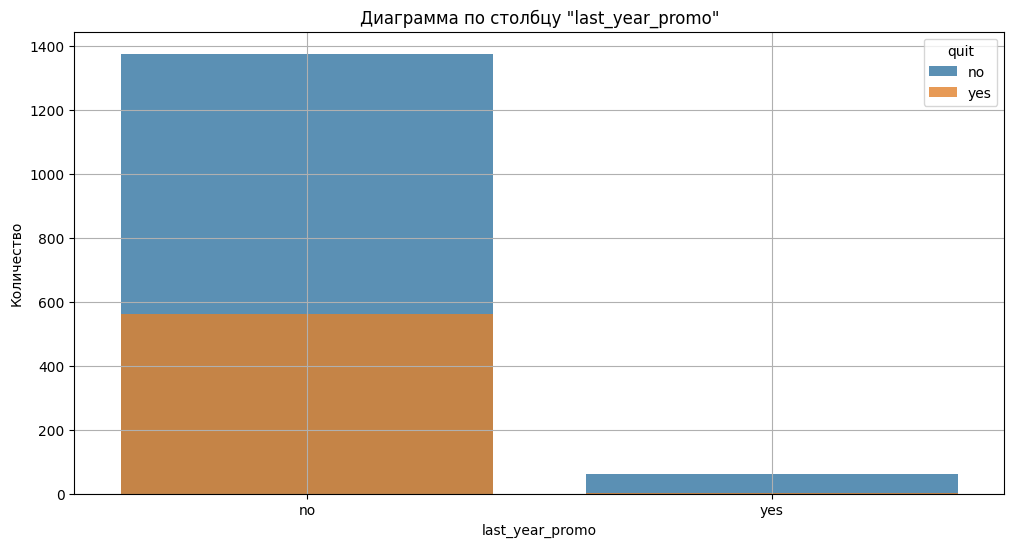

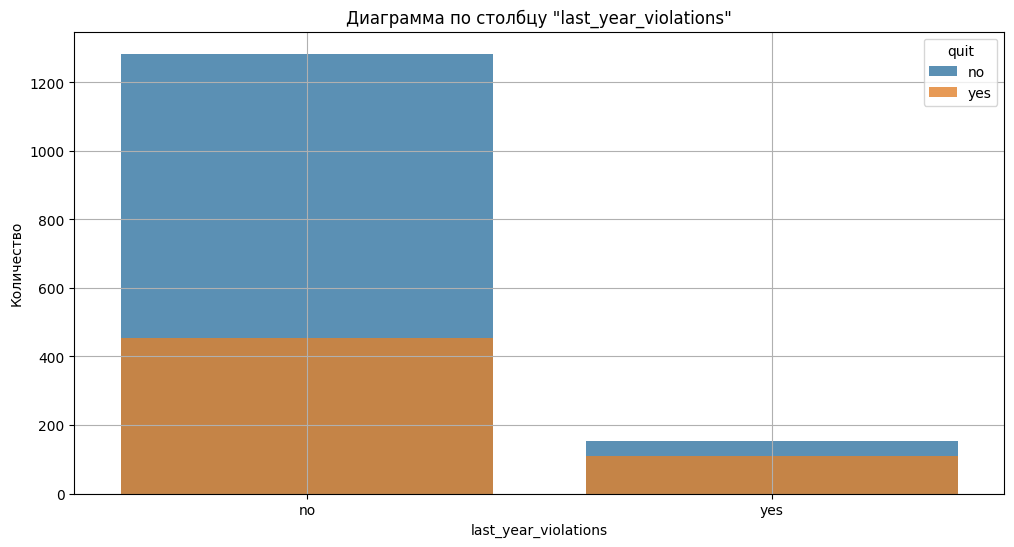

In [66]:
for col in df_portret_stay.select_dtypes('object'):
    sns.countplot(data=df_portret_stay, x=col, label='no', alpha=0.8)
    sns.countplot(data=df_portret_quit, x=col, label='yes', alpha=0.8)
    if df_portret_stay[col].nunique() > 3:
        plt.xticks(rotation=90)
    plt.grid(True)
    plt.ylabel('Количество')
    plt.title(f'Диаграмма по столбцу "{col}"')
    plt.legend(title='quit')
    plt.show()

##### Вывод

Портрет уволившегося сотрудника:
- Работал на протяжении 2 лет
- удовлетворен работой на 4 из 10
- имеет junior должность
- не повышен в должности

<a id='#4-bullet'></a>
### Шаг 4. Добавление нового входного признака
Допустим, job_satisfaction_rate и quit действительно связаны и вы получили необходимое значение метрики в первой задаче. Тогда добавьте job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.


In [67]:
dict_2[list_2[0]]['job_satisfaction_rate'] = best_model_1.predict(dict_2[list_2[0]])
dict_2[list_2[0]].head(5)

C:\Users\navoh\AppData\Local\Temp\ipykernel_1368\1483808061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dict_2[list_2[0]]['job_satisfaction_rate'] = best_model_1.predict(dict_2[list_2[0]])


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
100222,sales,junior,medium,3,no,no,2,20400,1,0.372751
100459,purchasing,junior,medium,3,no,no,3,21600,1,0.385634
100469,marketing,junior,medium,1,no,no,4,28800,0,0.644152
100601,technology,middle,high,4,no,no,4,68400,0,0.770135
100858,sales,junior,medium,2,no,no,4,25200,1,0.758507


In [68]:
dict_2[list_2[1]]['job_satisfaction_rate'] = best_model_1.predict(dict_2[list_2[1]])
dict_2[list_2[1]].head(5)

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.838234
100480,marketing,junior,low,4,no,no,4,16800,0.763523
100503,purchasing,middle,high,5,no,no,4,55200,0.728131
100610,sales,middle,medium,5,no,no,4,43200,0.813038
100692,sales,middle,high,6,no,no,4,48000,0.677592


#### Промежуточный итог
Предсказанные значения job_satisfaction_rate добавлены в тренировочную и тестовую выборку

<a id='#5-bullet'></a>
### Шаг 5. Подготовка данных
Подготовьте признаки так же, как и в первой задаче: выполните подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

In [69]:
dict_2.keys()

dict_keys(['train_quit', 'test_features', 'test_target_quit'])

In [70]:
X_train = dict_2[list_2[0]].drop(columns=['quit'])
y_train = dict_2[list_2[0]]['quit']
X_test = dict_2[list_2[1]]
y_test = dict_2[list_2[2]]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2587, 9), (2587,), (2000, 9), (2000, 1))

In [71]:
# создаём списки с названиями признаков
cat_columns = X_train.select_dtypes('object').columns.tolist()
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = X_train.select_dtypes('number').columns.tolist()

ord_categories = [['junior', 'middle', 'sinior'],
                  ['low','medium','high']]


In [235]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', 
                           handle_unknown='infrequent_if_exist',
                           sparse_output=False 
                           )),
     ('simpleImputer_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
    )


# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=ord_categories, 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
     ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)


# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)


# создаём итоговый пайплайн: подготовка данных и модель
pipe_classifier = Pipeline([
    ('preprocessor', data_preprocessor),
    ('smote_tomek', SMOTE(random_state=RANDOM_STATE)),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    # ('poly_features', PolynomialFeatures(degree=2, 
    #                                      order='C',
                                        #  interaction_only=True,
                                        #  include_bias=False,
                                        #  )),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])


#### Промежуточный итог

Пайплайн подготовлен

<a id='#6-bullet'></a>
### Шаг 6. Обучение модели
Обучите как минимум три модели. Как минимум для двух из них подберите гиперпараметры. Проверьте качество лучшей модели.

Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC ≥0.91 на тестовой выборке. Напомним: отбор признаков часто помогает улучшить метрику.

In [236]:
param_grid_classif_1 = [
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier(n_jobs=-1)],
        'models__n_neighbors': range(10,30, 2),
        'feature_selection__k': range(5, 12, 2),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
]

In [237]:
param_grid_classif_2 = [
    # словарь для модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE,
                    #    class_weight='balanced',
                       )],
        'models__C': range(1,15,5),
        'models__kernel': ['linear', 'rbf'],
        # 'feature_selection__k': range(5, 12, 2),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
]

In [238]:
param_grid_classif_3 = [
    # Словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE,
                                      n_jobs=-1
                                      )],
        'models__C': range(1, 36, 5),
        # 'models__penalty' : ['l1', 'l2'],
        # 'solver': ['saga', 'lbfgs'],
        'feature_selection__k': range(5, 12, 2),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [239]:
param_grid_classif_4 = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE,
                                        #   class_weight='balanced'
                                          )],
        'models__max_depth': range(2,7),
        'models__max_features': range(2,8),
        'models__min_samples_split':range(5,10),
        'models__min_samples_leaf':range(5,10),
        'feature_selection__k': range(5, 16, 2),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

#### KNeighborsClassifier

In [240]:
randomized_search_classif_knn = df_randomized_search_classifier(pipe_classifier, param_grid_classif_1, n_iter=20)
randomized_search_classif_knn.fit(X_train, y_train)
classif_knn_best = randomized_search_classif_knn.best_estimator_
print(f'Метрика ROC_AUC модели: {randomized_search_classif_knn.best_score_}')
classif_knn_best

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be

Метрика ROC_AUC модели: 0.9097084721878567


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary',
                                                   'job_satisfaction_rate'])])),
                ('smote_tomek', SMOTE(random_state=57)),
                ('feature_selection', SelectKBest(k=7)),
                ('models', KNeighborsClassifier(n_jobs=-1, n_neighbors=18))])

#### SVC

In [241]:
randomized_search_classif_svc = df_randomized_search_classifier(pipe_classifier, param_grid_classif_2)
randomized_search_classif_svc.fit(X_train, y_train)
classif_svc_best = randomized_search_classif_svc.best_estimator_

print(f'Метрика ROC_AUC модели: {randomized_search_classif_svc.best_score_}')
classif_svc_best

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be

Метрика ROC_AUC модели: 0.9092776079687498


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary',
                                                   'job_satisfaction_rate'])])),
                ('smote_tomek', SMOTE(random_state=57)),
                ('feature_selection', SelectKBest()),
                ('models', SVC(C=1, random_state=57))])

#### LogisticRegression

In [242]:
randomized_search_classif_log = df_randomized_search_classifier(pipe_classifier, param_grid_classif_3)
randomized_search_classif_log.fit(X_train, y_train)
classif_log_best = randomized_search_classif_log.best_estimator_

print(f'Метрика ROC_AUC модели: {randomized_search_classif_log.best_score_}');
classif_log_best

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be

Метрика ROC_AUC модели: 0.9020254798369793


c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary',
                                                   'job_satisfaction_rate'])])),
                ('smote_tomek', SMOTE(random_state=57)),
                ('feature_selection', SelectKBest(k=9)),
                ('models',
                 LogisticRegression(C=16, n_jobs=-1, random_state=57))])

#### DecisionTreeClassifier

In [243]:
randomized_search_classif_tree = df_randomized_search_classifier(pipe_classifier, param_grid_classif_4)
randomized_search_classif_tree.fit(X_train, y_train)
classif_tree_best = randomized_search_classif_tree.best_estimator_

print(f'Метрика ROC_AUC модели: {randomized_search_classif_tree.best_score_}');
classif_tree_best

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be

Метрика ROC_AUC модели: 0.8958512123383455


c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=15 is greater than n_feature

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary',
                                                   'job_satisfaction_rate'])])),
                ('smote_tomek', SMOTE(random_state=57)),
                ('feature_selection', SelectKBest(k=15)),
                ('models',
                 DecisionTreeClassifier(max_depth=6, max_features=6,
                                        min_samples_leaf=9, min_samples_split=5,
                                        random_state=57))])

#### Выбор лучшей модели

In [244]:
best_score_2 = 0
best_model_2 = []
for i in [randomized_search_classif_knn, 
          randomized_search_classif_log, 
          randomized_search_classif_svc,
          randomized_search_classif_tree]:
    if i.best_score_ > best_score_2:
        best_score_2 = i.best_score_
        best_model_2 = i.best_estimator_
print(f'Метрика ROC-AUC лучшей модели: {best_score_2}')
print('Лучшая модель:')
best_model_2

Метрика ROC-AUC лучшей модели: 0.9097084721878567
Лучшая модель:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept', 'last_...
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary',
                                                   'job_satisfaction_rate'])])),
                ('smote_tomek', SMOTE(random_state=57)),
                ('feature_selection', SelectKBest(k=7)),
                ('models', KNeighborsClassifier(n_jobs=-1, n_neighbors=18))])

Тестирование лучшей модели на тестовых данных

In [245]:
show_metrics_classifier(best_model_2, X_test, y_test)

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,ROC-AUC,Accuracy,f1
На тестовой выборке,0.864,0.85,0.771


<a id='#7-bullet'></a>
### Шаг 7. Выводы
Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.


Согласно метрики ROC_AUC, лучше всего справилась модель Логистической регрессии с результатом 0,506

<a id='#10-bullet'></a>
## Общий вывод

Сформулируйте общий вывод:
опишите задачу;
опишите все этапы работы;
добавьте выводы и дополнительные предложения для бизнеса.

Первая задача - Построить модель, которая сможет предсказать уровень удовлетворенности сотрудника на основе данных от заказчика.

В ходе решения данной задачи были проведены этапы: 
- предобработки данных - проверка на дубликаты и пропуски данных
- исследовательского анализа - поиск выбросов и аномалий, зависимостей, корреляционный анализ
- подготовки данных с помощью пайплайна, который включает кодирование и масштабирование данных, а также заполнение пропусков данных

В ходе обучения моделей были испробованы: LinearRegression, KNeighbosrRegression, DecisionTreeRegression, SVR. В итоге лучшая модель по метрике SMAPE оказалась модель SVR с гиперпараметром C=4.

Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

В ходе решения были воплнены те же самые шаги, что и для первой, за исключенияем добавления результатов первой модели к данным для тестирования.

В ходе обучения моделей были испробованы: LogisticRegression, KNeighborsClassifier, DecisionTreeClassifier, SVc. В итоге лучшая модель по метрике ROC-AUC оказалась модель LogisticRegression.

Также был составлен портрет уволившегося сотрудника.

Портрет уволившегося сотрудника:
- Работал на протяжении 2 лет
- удовлетворен работой на 4 из 10
- имеет junior должность
- не повышен в должности
